# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from fm.seed import set_seed
import fm.data as data
import fm.model as model
import fm.training as training
import fm.physics as physics
import fm.massesPlots as massesPlots
import fm.lossPlots as lossPlots
import fm.analysis as analysis

In [3]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})

# Load the Datasets

In [4]:
with open("df_H_event.pkl", "rb") as f:
    df_H_event = pickle.load(f)

with open("df_DY_event.pkl", "rb") as f:
    df_DY_event = pickle.load(f)

# Define Target and Context

In [5]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt", 
    # "tau1_ptreco_over_ptgen",
 #   "gen_tau1_logpt"
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
    # "tau2_ptreco_over_ptgen",
  #  "gen_tau2_logpt",
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_significance","MET_sumEt"
]

train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols
)

y_cols = ["tau1_corr", "tau2_corr"]

# DataFrames Splitting

In [16]:
# Creo i dataframe : 
#   1. All
#   2. Bilanciato

df_all = (
    pd.concat([df_DY_event, df_H_event], axis=0)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)

df_bal = data.make_balanced_df(df_all, seed=0)

print("df_all:", df_all.shape)
print("df_bal:", df_bal.shape)
print("Counts df_all:", df_all["class"].value_counts().to_dict())
print("Counts df_bal:", df_bal["class"].value_counts().to_dict())

df_all: (337351, 76)
df_bal: (163894, 76)
Counts df_all: {1: 255404, 0: 81947}
Counts df_bal: {1: 81947, 0: 81947}


In [17]:
# Splitting :
df_train_all, df_val_all, df_test_all = data.split_df_once(df_all, seed=0)

print("SPLITS df_all:")
print("train:", df_train_all.shape, df_train_all["class"].value_counts().to_dict())
print("val  :", df_val_all.shape,   df_val_all["class"].value_counts().to_dict())
print("test :", df_test_all.shape,  df_test_all["class"].value_counts().to_dict())

df_train_bal, df_val_bal, df_test_bal = data.split_df_once(df_bal, seed=0)

print("SPLITS df_bal:")
print("train:", df_train_bal.shape, df_train_bal["class"].value_counts().to_dict())
print("val  :", df_val_bal.shape,   df_val_bal["class"].value_counts().to_dict())
print("test :", df_test_bal.shape,  df_test_bal["class"].value_counts().to_dict())

SPLITS df_all:
train: (269880, 76) {1: 204276, 0: 65604}
val  : (33735, 76) {1: 25636, 0: 8099}
test : (33736, 76) {1: 25492, 0: 8244}
SPLITS df_bal:
train: (131115, 76) {1: 65596, 0: 65519}
val  : (16389, 76) {0: 8228, 1: 8161}
test : (16390, 76) {0: 8200, 1: 8190}


In [18]:
# Scaling :
SCALING_MODES = [
    "X_NONE__Y_NONE",
    "X_GLOBAL__Y_LOCAL",
    "X_GLOBAL__Y_GLOBAL",
    "X_LOCAL__Y_LOCAL",
    "X_NONE__Y_LOCAL",
]

OUTDIR = "../results/prepared_splits"   # relativo a notebooks/
os.makedirs(OUTDIR, exist_ok=True)

In [19]:
paths_unbalanced = data.apply_and_save_all_scalings(
    df_train_all, df_val_all, df_test_all,
    dataset_tag="unbalanced",
    train_cols=train_cols,
    y_cols=y_cols,
    outdir=OUTDIR,
)

paths_balanced = data.apply_and_save_all_scalings(
    df_train_bal, df_val_bal, df_test_bal,
    dataset_tag="balanced",
    train_cols=train_cols,
    y_cols=y_cols,
    outdir=OUTDIR,
)

[unbalanced] saved X_NONE__Y_NONE -> ../results/prepared_splits/unbalanced/X_NONE__Y_NONE
[unbalanced] saved X_GLOBAL__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_GLOBAL__Y_LOCAL
[unbalanced] saved X_GLOBAL__Y_GLOBAL -> ../results/prepared_splits/unbalanced/X_GLOBAL__Y_GLOBAL
[unbalanced] saved X_LOCAL__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_LOCAL__Y_LOCAL
[unbalanced] saved X_NONE__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_NONE__Y_LOCAL
[balanced] saved X_NONE__Y_NONE -> ../results/prepared_splits/balanced/X_NONE__Y_NONE
[balanced] saved X_GLOBAL__Y_LOCAL -> ../results/prepared_splits/balanced/X_GLOBAL__Y_LOCAL
[balanced] saved X_GLOBAL__Y_GLOBAL -> ../results/prepared_splits/balanced/X_GLOBAL__Y_GLOBAL
[balanced] saved X_LOCAL__Y_LOCAL -> ../results/prepared_splits/balanced/X_LOCAL__Y_LOCAL
[balanced] saved X_NONE__Y_LOCAL -> ../results/prepared_splits/balanced/X_NONE__Y_LOCAL


# Trainings

In [20]:
# Balanced MSE pat30
results_balanced_mse_pat30 = {}

for mode, mode_dir in paths_balanced.items():
    print("\n" + "="*90)
    print(f"TRAIN BALANCED — {mode} — MSE pat30")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="mse",
        patience=30,
    )

    results_balanced_mse_pat30[mode] = res

# Balanced MSE pat 100

results_balanced_mse_pat100 = {}

for mode, mode_dir in paths_balanced.items():
    print("\n" + "="*90)
    print(f"TRAIN BALANCED — {mode} — MSE pat100")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="mse",
        patience=100,
    )

    results_balanced_mse_pat100[mode] = res

# Balanced HUBER pat 30
results_balanced_huber_pat30 = {}

for mode, mode_dir in paths_balanced.items():
    print("\n" + "="*90)
    print(f"TRAIN BALANCED — {mode} — HUBER pat30")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="huber",
        huber_delta=1.0,
        patience=30,
    )

    results_balanced_huber_pat30[mode] = res

# Balanced HUBER pat 100
results_balanced_huber_pat100 = {}

for mode, mode_dir in paths_balanced.items():
    print("\n" + "="*90)
    print(f"TRAIN BALANCED — {mode} — HUBER pat100")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="huber",
        huber_delta=1.0,
        patience=100,
    )

    results_balanced_huber_pat100[mode] = res


TRAIN BALANCED — X_NONE__Y_NONE — MSE pat30
[ep    1] train=3.283841  val=1.219744  best=1.219744  bad=0/30
[ep   10] train=1.099736  val=1.265179  best=1.067246  bad=7/30
[ep   20] train=1.036451  val=1.038821  best=1.038821  bad=0/30
[ep   30] train=0.999285  val=0.919970  best=0.919970  bad=0/30
[ep   40] train=0.917015  val=0.806328  best=0.806328  bad=0/30
[ep   50] train=0.800898  val=0.784576  best=0.731861  bad=3/30
[ep   60] train=0.683231  val=0.869003  best=0.591558  bad=2/30
[ep   70] train=0.628277  val=0.584788  best=0.584788  bad=0/30
[ep   80] train=0.725660  val=0.589618  best=0.516213  bad=2/30
[ep   90] train=0.585796  val=0.929260  best=0.498471  bad=1/30
[ep  100] train=0.598274  val=0.852351  best=0.498471  bad=11/30
[ep  110] train=0.752143  val=0.667682  best=0.498471  bad=21/30
Early stopping at ep 119 (best val=0.498471)

TRAIN BALANCED — X_GLOBAL__Y_LOCAL — MSE pat30
[ep    1] train=1.940617  val=1.967368  best=1.967368  bad=0/30
[ep   10] train=1.391921  va

In [21]:
# Save the runs:
OUT_ROOT = "../results/runs_prepared"
dataset_tag = "balanced"
loss_tag = "MSE_pat30"

for mode, res in results_balanced_mse_pat30.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

loss_tag = "MSE_pat100"

for mode, res in results_balanced_mse_pat100.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

loss_tag = "HUBER_d1_pat30"

for mode, res in results_balanced_huber_pat30.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

loss_tag = "HUBER_d1_pat100"

for mode, res in results_balanced_huber_pat100.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

saved -> ../results/runs_prepared/balanced/MSE_pat30/X_NONE__Y_NONE
saved -> ../results/runs_prepared/balanced/MSE_pat30/X_GLOBAL__Y_LOCAL
saved -> ../results/runs_prepared/balanced/MSE_pat30/X_GLOBAL__Y_GLOBAL
saved -> ../results/runs_prepared/balanced/MSE_pat30/X_LOCAL__Y_LOCAL
saved -> ../results/runs_prepared/balanced/MSE_pat30/X_NONE__Y_LOCAL
saved -> ../results/runs_prepared/balanced/MSE_pat100/X_NONE__Y_NONE
saved -> ../results/runs_prepared/balanced/MSE_pat100/X_GLOBAL__Y_LOCAL
saved -> ../results/runs_prepared/balanced/MSE_pat100/X_GLOBAL__Y_GLOBAL
saved -> ../results/runs_prepared/balanced/MSE_pat100/X_LOCAL__Y_LOCAL
saved -> ../results/runs_prepared/balanced/MSE_pat100/X_NONE__Y_LOCAL
saved -> ../results/runs_prepared/balanced/HUBER_d1_pat30/X_NONE__Y_NONE
saved -> ../results/runs_prepared/balanced/HUBER_d1_pat30/X_GLOBAL__Y_LOCAL
saved -> ../results/runs_prepared/balanced/HUBER_d1_pat30/X_GLOBAL__Y_GLOBAL
saved -> ../results/runs_prepared/balanced/HUBER_d1_pat30/X_LOCAL__Y_

In [22]:
# Unbalanced MSE pat30
results_unbalanced_mse_pat30 = {}

for mode, mode_dir in paths_unbalanced.items():
    print("\n" + "="*90)
    print(f"TRAIN UNBALANCED — {mode} — MSE pat30")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="mse",
        patience=30,
    )

    results_unbalanced_mse_pat30[mode] = res


# Unbalanced MSE pat100
results_unbalanced_mse_pat100 = {}

for mode, mode_dir in paths_unbalanced.items():
    print("\n" + "="*90)
    print(f"TRAIN UNBALANCED — {mode} — MSE pat100")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="mse",
        patience=100,
    )

    results_unbalanced_mse_pat100[mode] = res


# Unbalanced HUBER pat30
results_unbalanced_huber_pat30 = {}

for mode, mode_dir in paths_unbalanced.items():
    print("\n" + "="*90)
    print(f"TRAIN UNBALANCED — {mode} — HUBER pat30")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="huber",
        huber_delta=1.0,
        patience=30,
    )

    results_unbalanced_huber_pat30[mode] = res


# Unbalanced HUBER pat100
results_unbalanced_huber_pat100 = {}

for mode, mode_dir in paths_unbalanced.items():
    print("\n" + "="*90)
    print(f"TRAIN UNBALANCED — {mode} — HUBER pat100")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="huber",
        huber_delta=1.0,
        patience=100,
    )

    results_unbalanced_huber_pat100[mode] = res


TRAIN UNBALANCED — X_NONE__Y_NONE — MSE pat30
[ep    1] train=2.549630  val=1.121649  best=1.121649  bad=0/30
[ep   10] train=1.012610  val=1.002283  best=1.002283  bad=0/30
[ep   20] train=0.784775  val=0.797501  best=0.779747  bad=2/30
[ep   30] train=0.799761  val=0.672443  best=0.663525  bad=4/30
[ep   40] train=0.670253  val=0.690331  best=0.610071  bad=2/30
[ep   50] train=0.611090  val=0.571100  best=0.565102  bad=1/30
[ep   60] train=1.279962  val=1.059099  best=0.544758  bad=3/30
[ep   70] train=0.699272  val=0.682116  best=0.544758  bad=13/30
[ep   80] train=0.628608  val=0.605504  best=0.544758  bad=23/30
Early stopping at ep 87 (best val=0.544758)

TRAIN UNBALANCED — X_GLOBAL__Y_LOCAL — MSE pat30
[ep    1] train=1.859058  val=1.719920  best=1.719920  bad=0/30
[ep   10] train=1.207075  val=1.205610  best=1.205610  bad=0/30
[ep   20] train=1.085856  val=1.096253  best=1.096253  bad=0/30
[ep   30] train=1.056555  val=1.056863  best=1.056863  bad=0/30
[ep   40] train=1.032393 

In [23]:
# Save the runs:
OUT_ROOT = "../results/runs_prepared"
dataset_tag = "unbalanced"
loss_tag = "MSE_pat30"

for mode, res in results_unbalanced_mse_pat30.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

loss_tag = "MSE_pat100"

for mode, res in results_unbalanced_mse_pat100.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

loss_tag = "HUBER_d1_pat30"

for mode, res in results_unbalanced_huber_pat30.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

loss_tag = "HUBER_d1_pat100"

for mode, res in results_unbalanced_huber_pat100.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

saved -> ../results/runs_prepared/unbalanced/MSE_pat30/X_NONE__Y_NONE
saved -> ../results/runs_prepared/unbalanced/MSE_pat30/X_GLOBAL__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/MSE_pat30/X_GLOBAL__Y_GLOBAL
saved -> ../results/runs_prepared/unbalanced/MSE_pat30/X_LOCAL__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/MSE_pat30/X_NONE__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/MSE_pat100/X_NONE__Y_NONE
saved -> ../results/runs_prepared/unbalanced/MSE_pat100/X_GLOBAL__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/MSE_pat100/X_GLOBAL__Y_GLOBAL
saved -> ../results/runs_prepared/unbalanced/MSE_pat100/X_LOCAL__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/MSE_pat100/X_NONE__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/HUBER_d1_pat30/X_NONE__Y_NONE
saved -> ../results/runs_prepared/unbalanced/HUBER_d1_pat30/X_GLOBAL__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/HUBER_d1_pat30/X_GLOBAL__Y_GLOBAL
saved -> ../results/runs_prepared/unbalance

# Plots
-----

## Loss
---

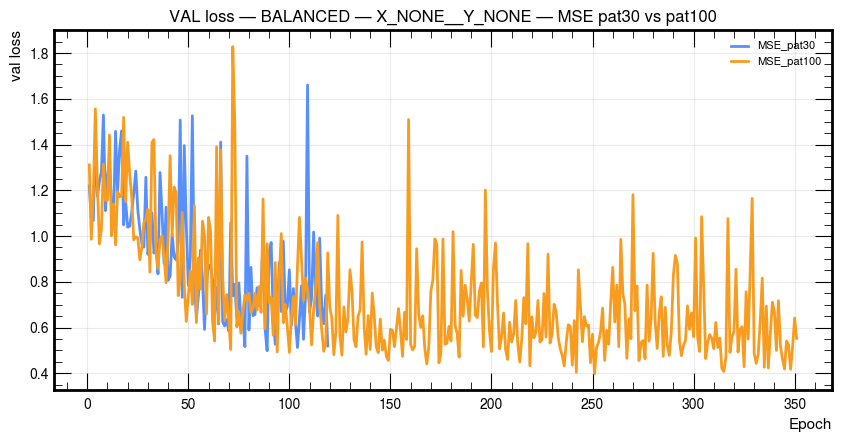

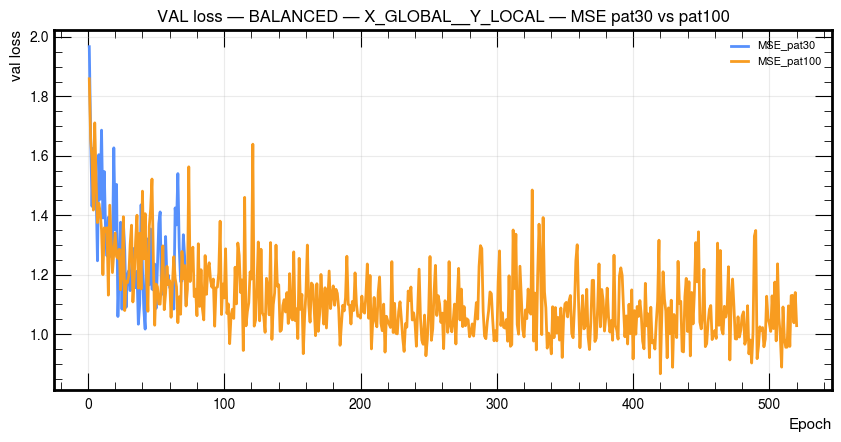

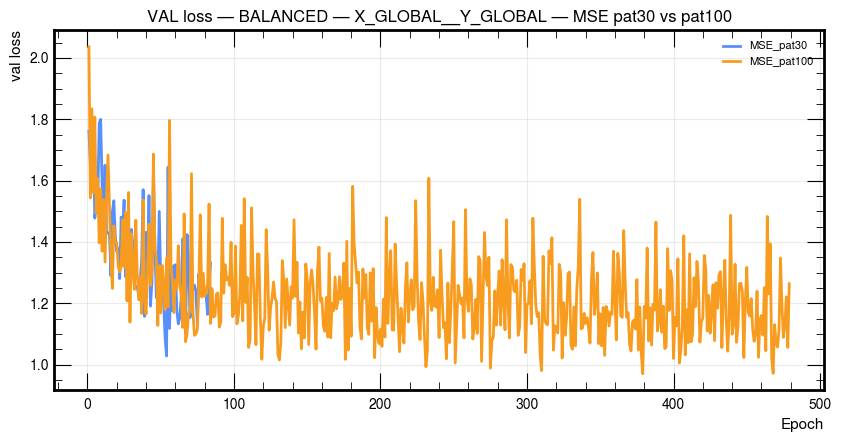

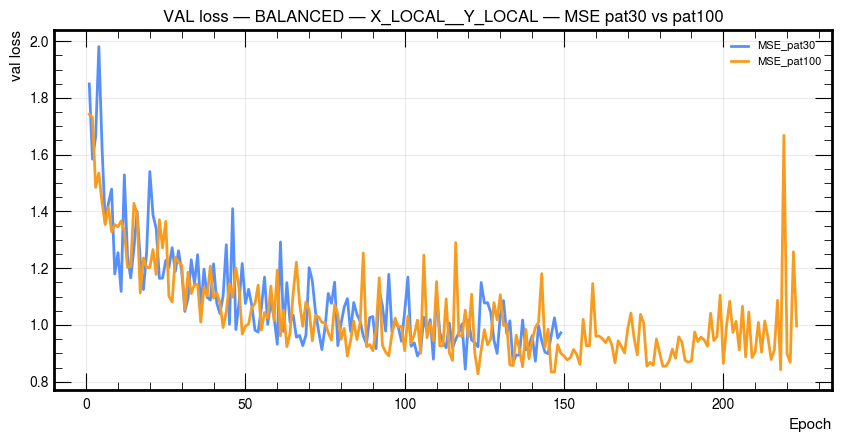

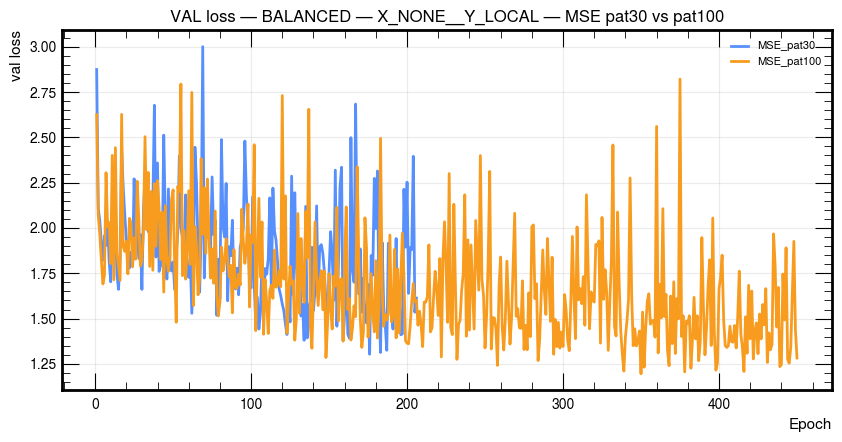

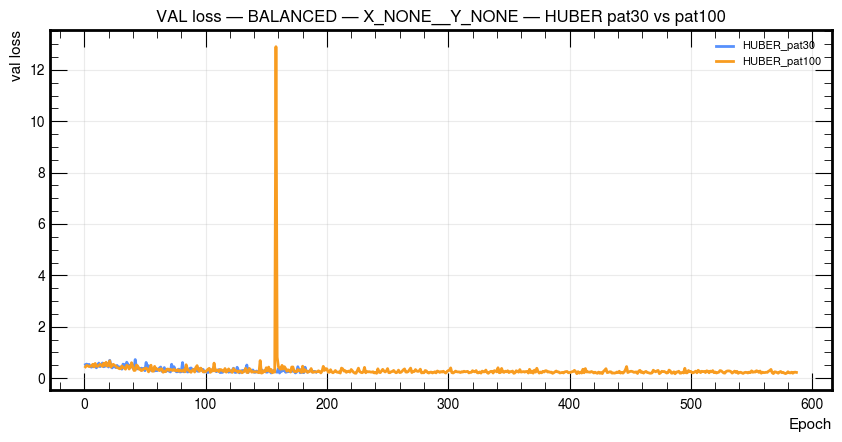

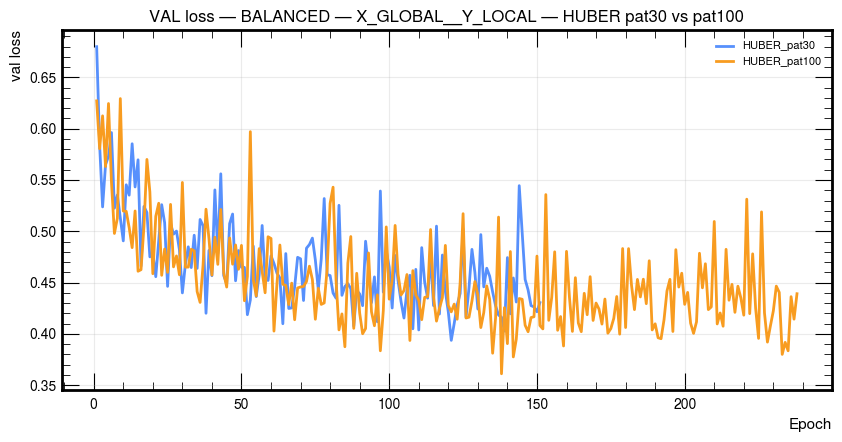

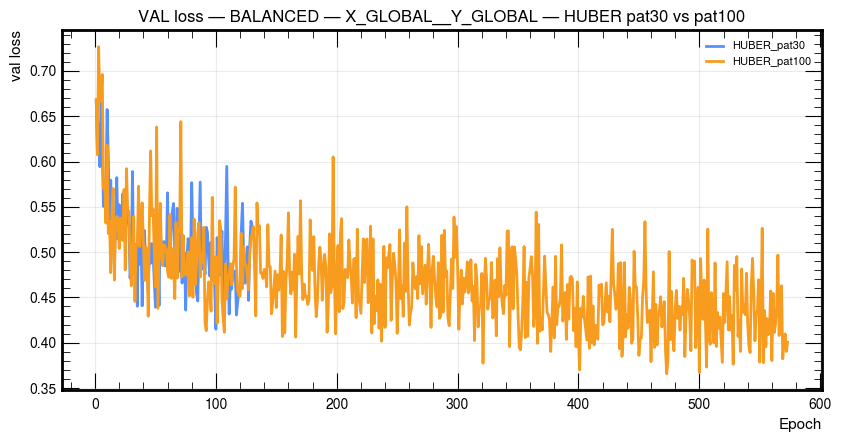

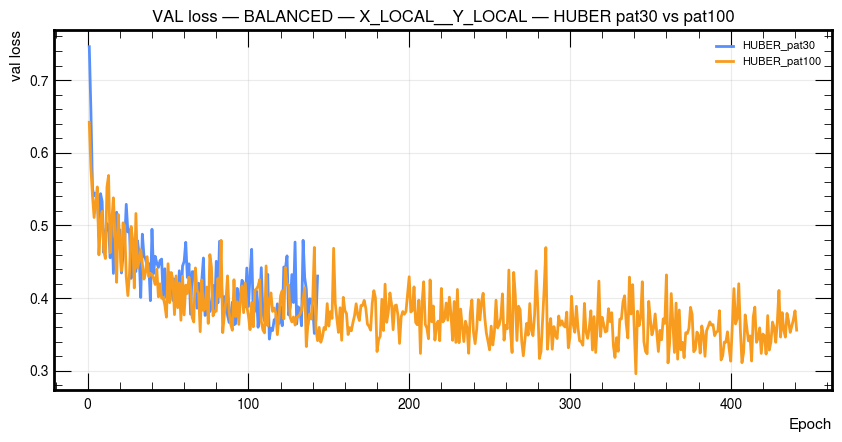

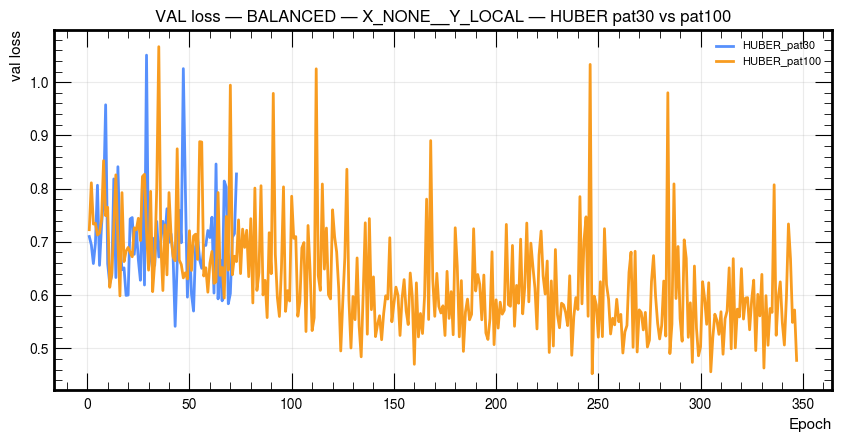

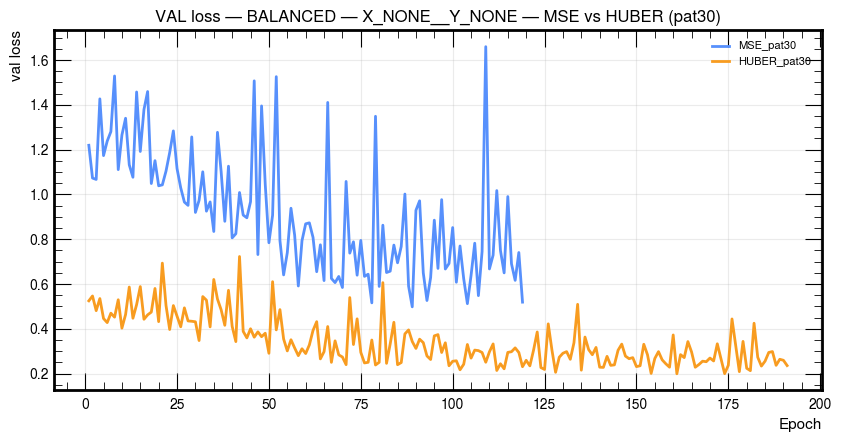

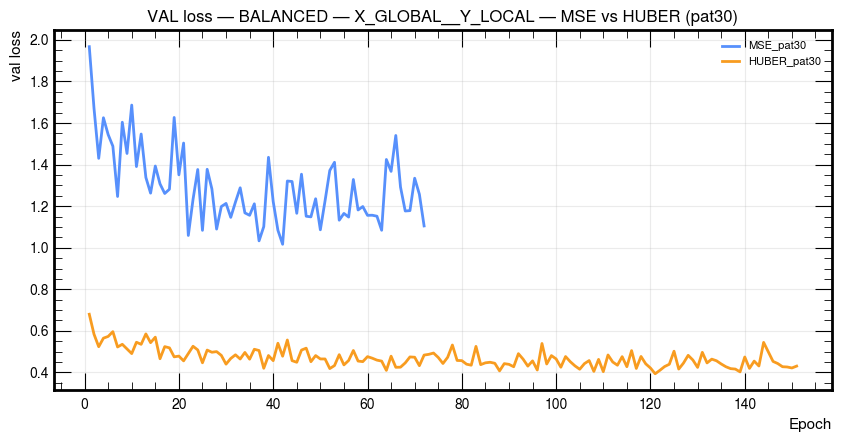

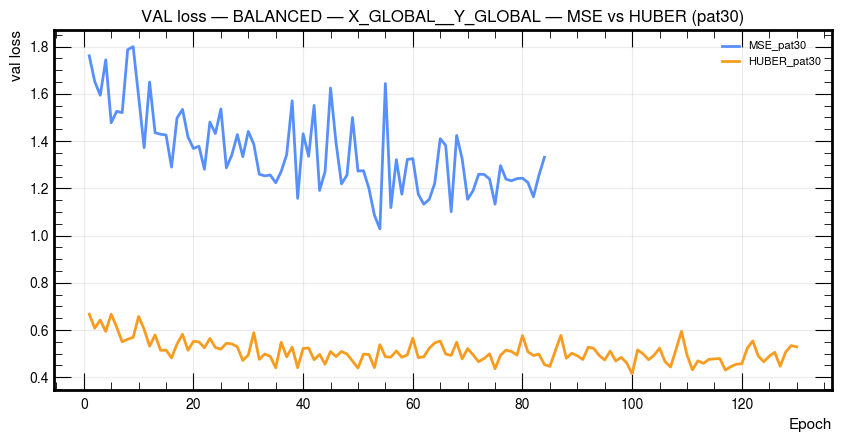

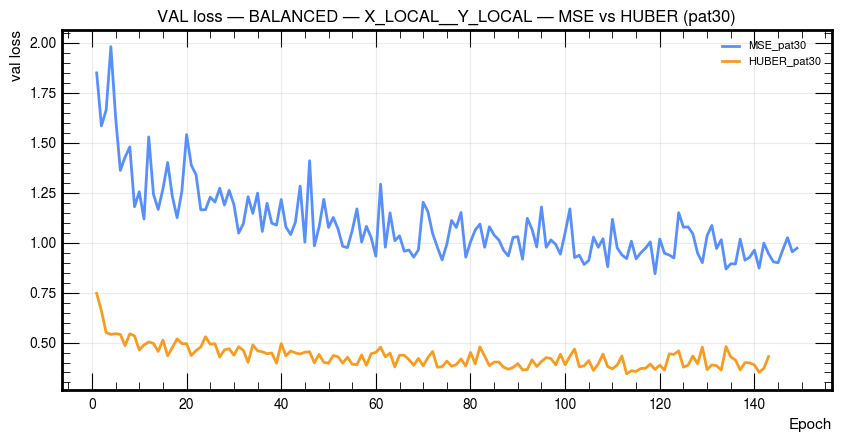

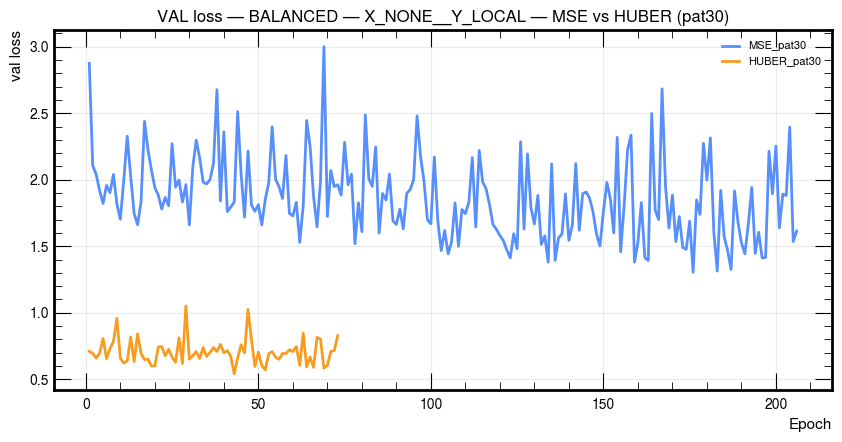

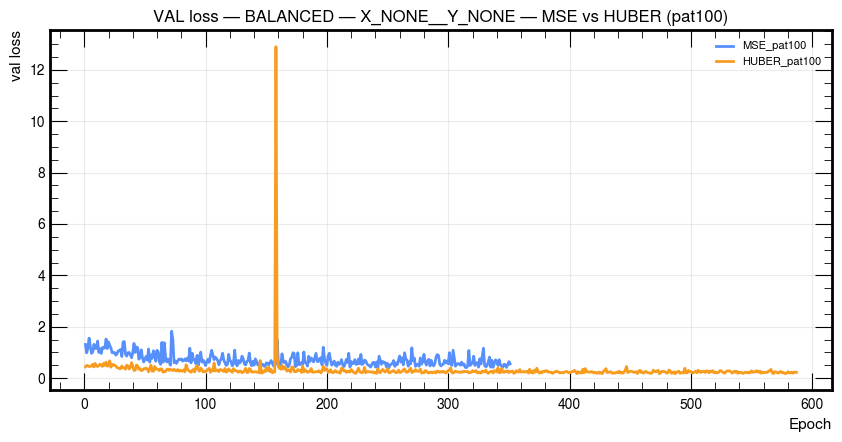

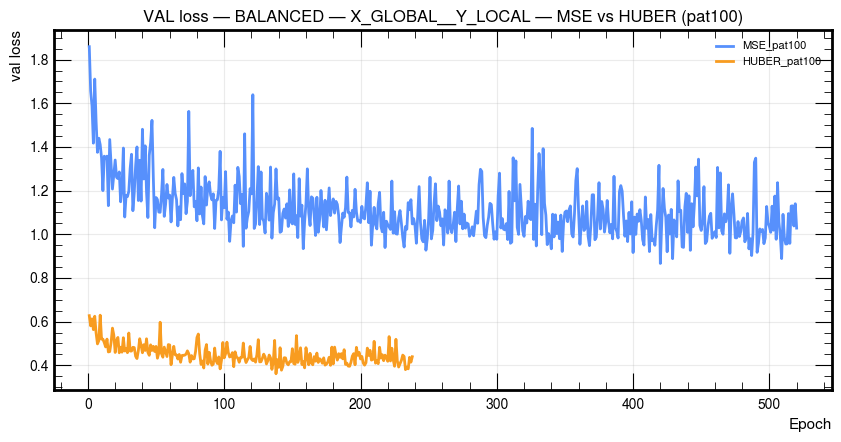

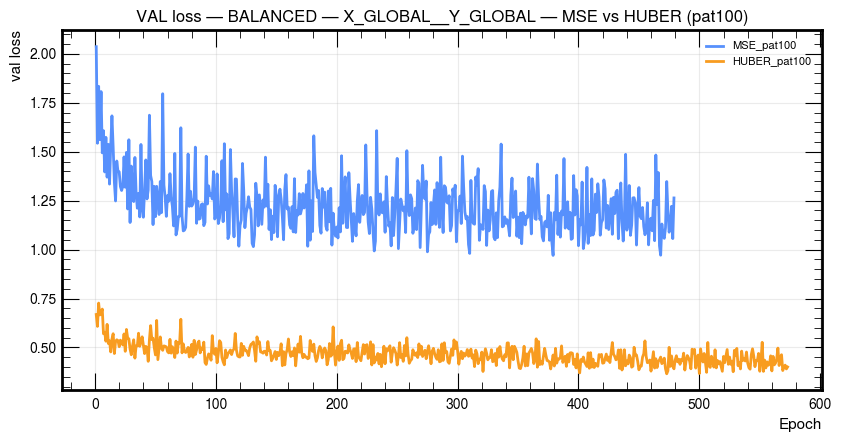

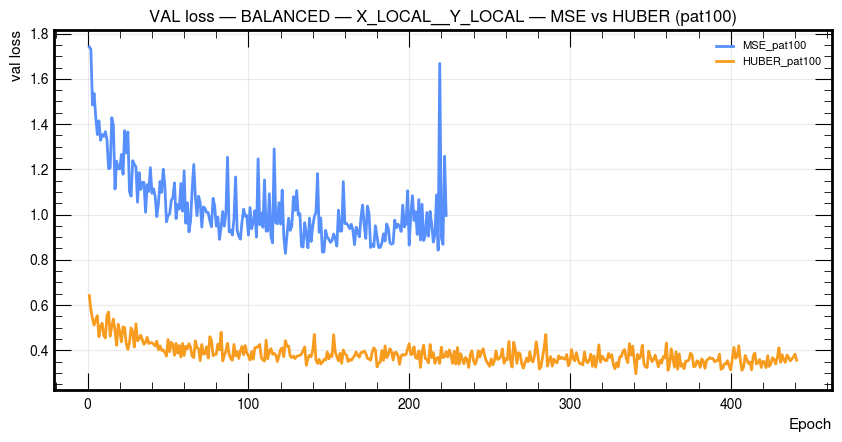

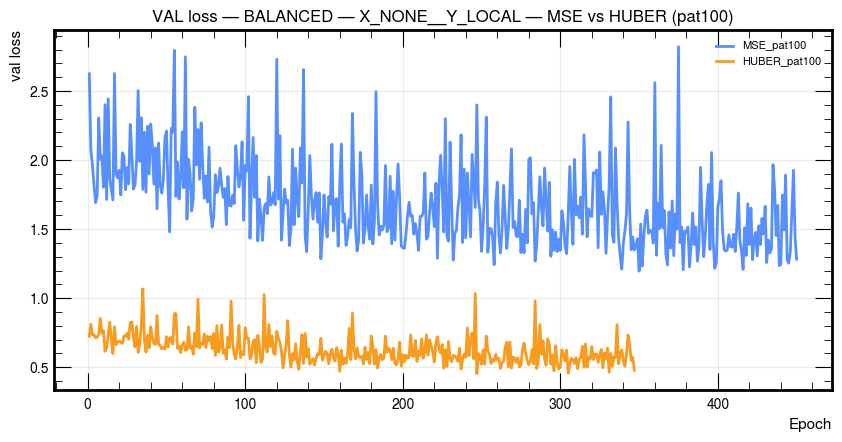

In [ ]:
for mode in SCALING_MODES:

    lossPlots.plot_loss_overlay(
        {
            "MSE_pat30": results_balanced_mse_pat30[mode],
            "MSE_pat100": results_balanced_mse_pat100[mode],
        },
        title=f"VAL loss — BALANCED — {mode} — MSE pat30 vs pat100",
        which="val",
        logy=False,
    )

for mode in SCALING_MODES:

    lossPlots.plot_loss_overlay(
        {
            "HUBER_pat30": results_balanced_huber_pat30[mode],
            "HUBER_pat100": results_balanced_huber_pat100[mode],
        },
        title=f"VAL loss — BALANCED — {mode} — HUBER pat30 vs pat100",
        which="val",
        logy=False,
    )

for mode in SCALING_MODES:

    lossPlots.plot_loss_overlay(
        {
            "MSE_pat30": results_balanced_mse_pat30[mode],
            "HUBER_pat30": results_balanced_huber_pat30[mode],
        },
        title=f"VAL loss — BALANCED — {mode} — MSE vs HUBER (pat30)",
        which="val",
        logy=False,
    )

for mode in SCALING_MODES:

    lossPlots.plot_loss_overlay(
        {
            "MSE_pat100": results_balanced_mse_pat100[mode],
            "HUBER_pat100": results_balanced_huber_pat100[mode],
        },
        title=f"VAL loss — BALANCED — {mode} — MSE vs HUBER (pat100)",
        which="val",
        logy=False,
    )

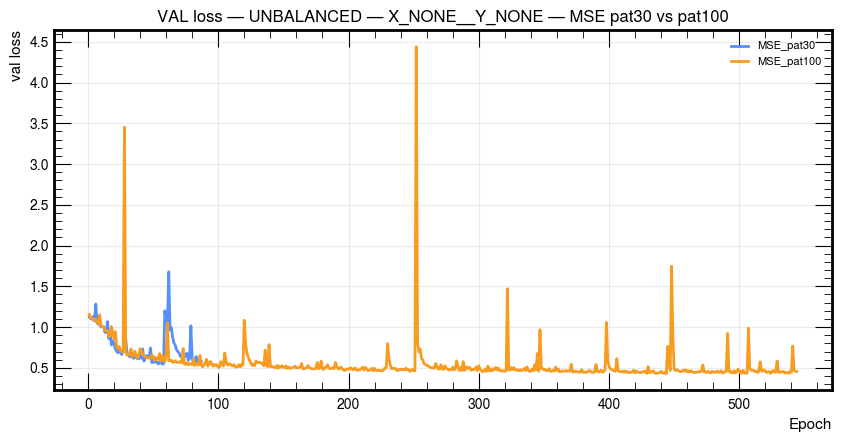

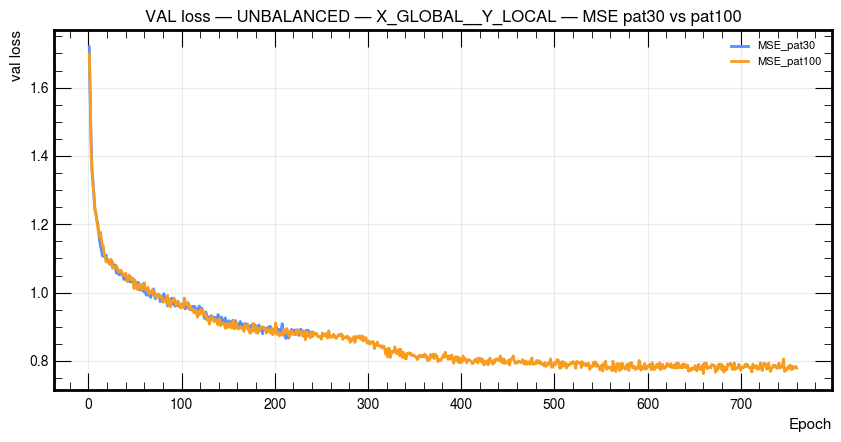

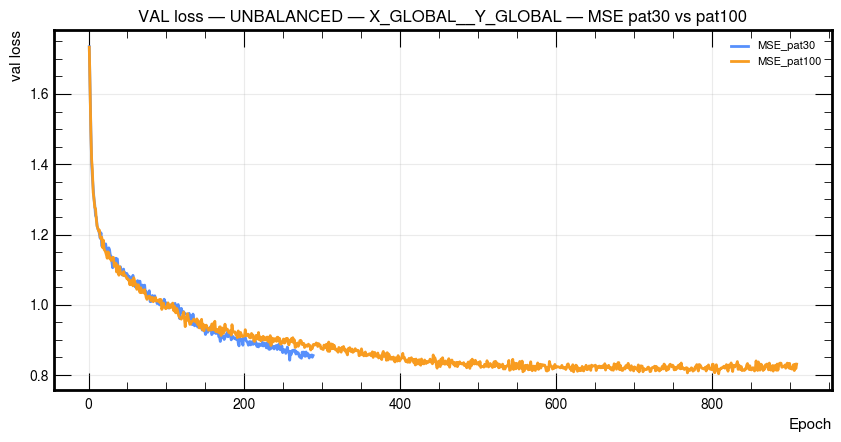

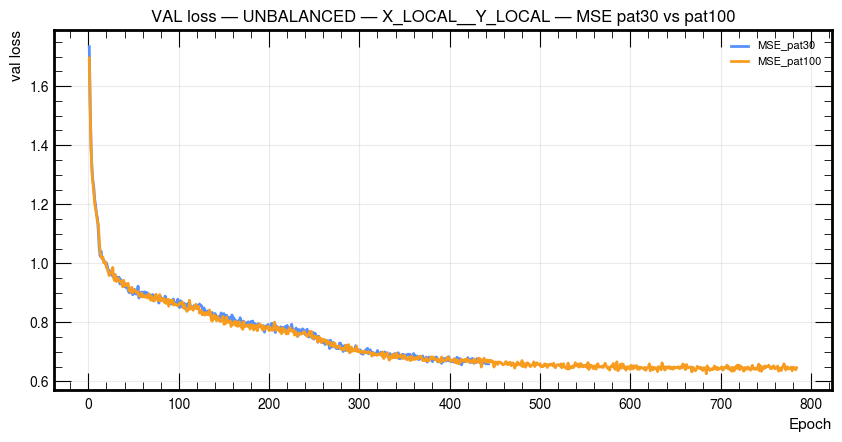

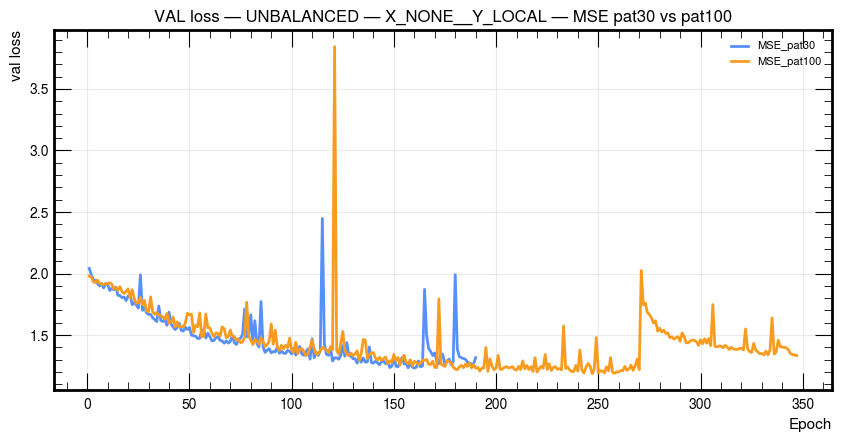

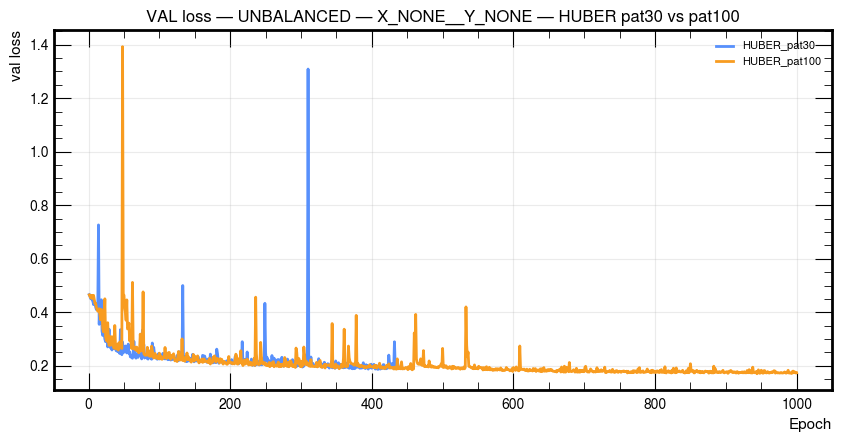

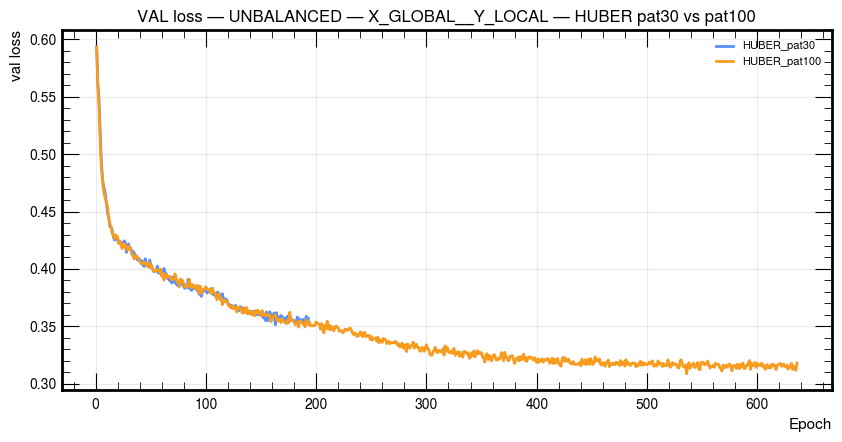

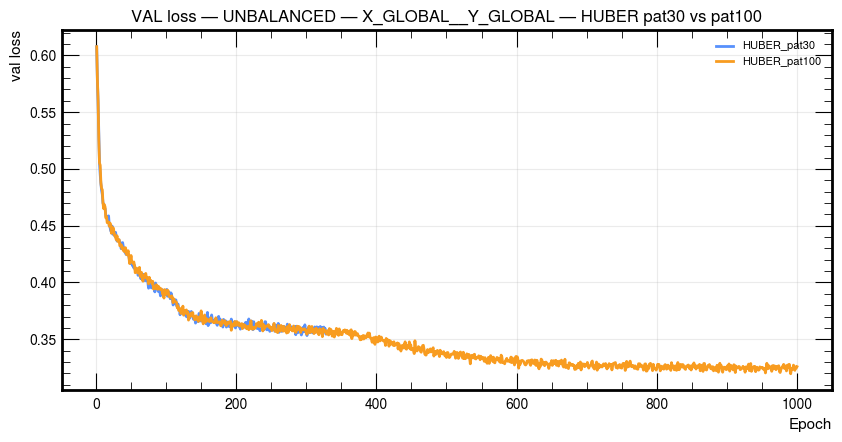

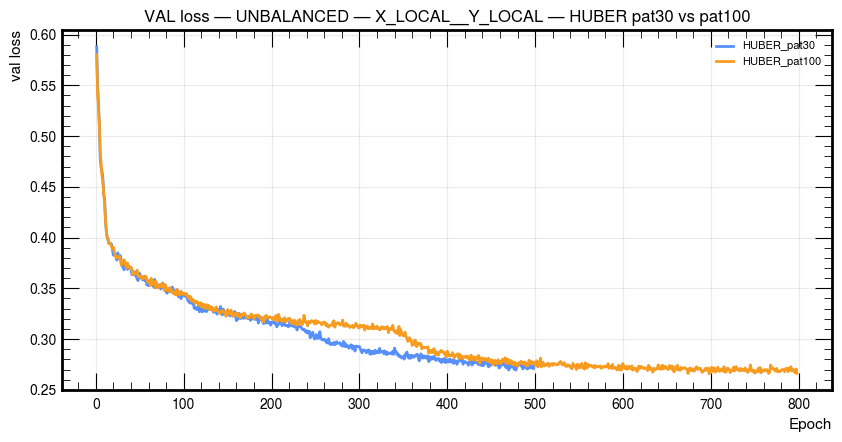

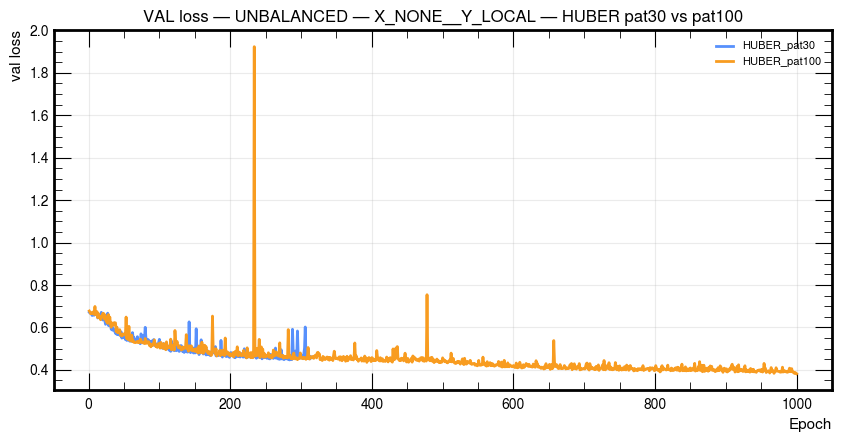

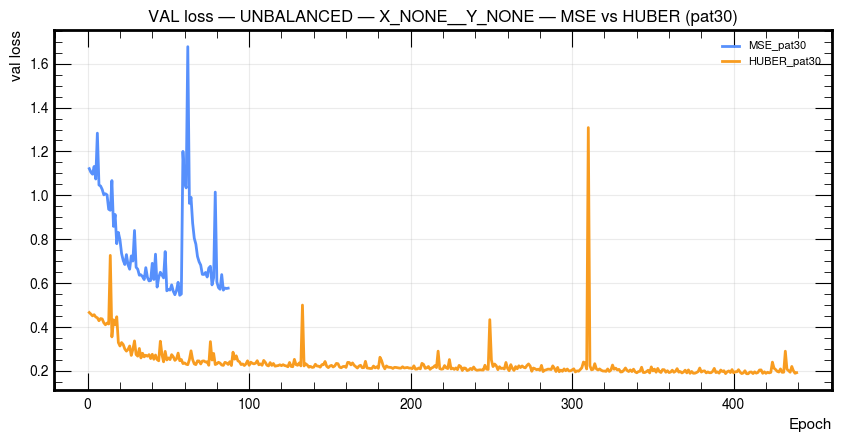

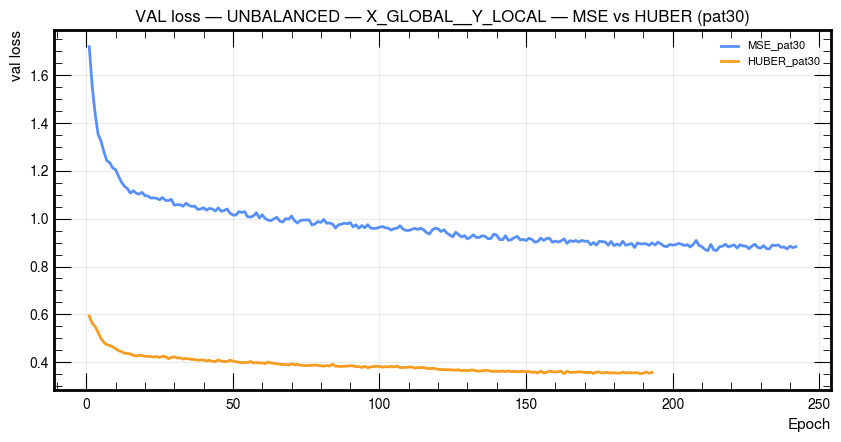

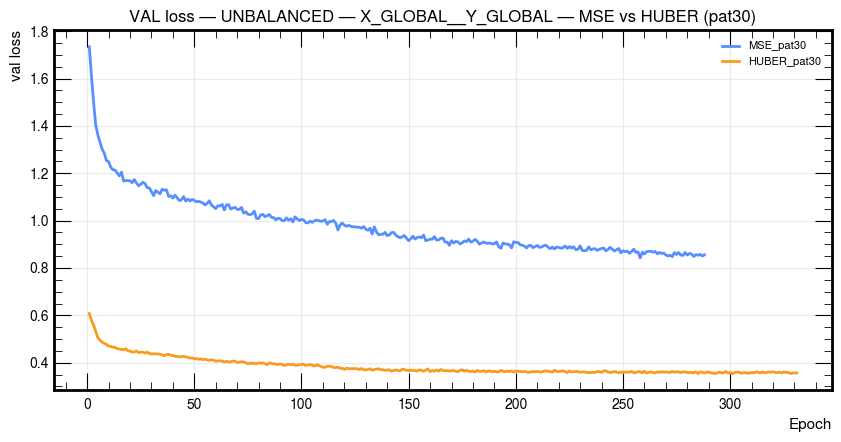

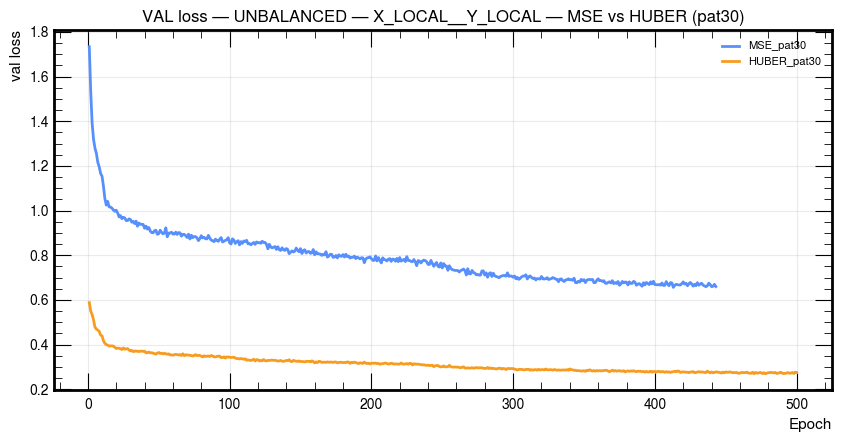

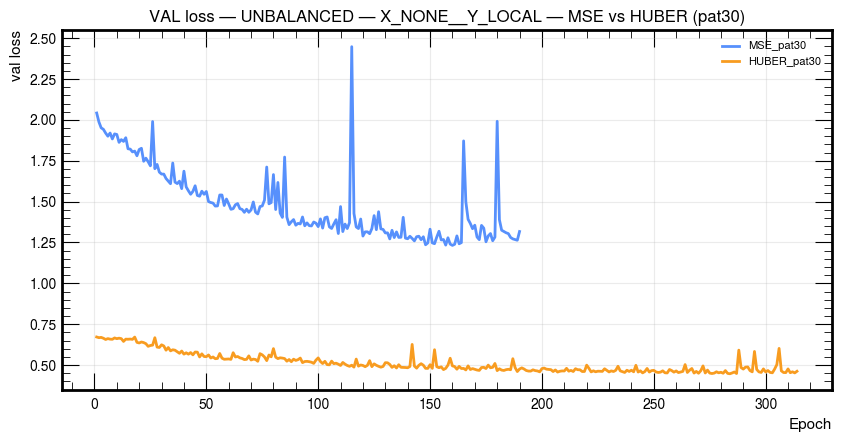

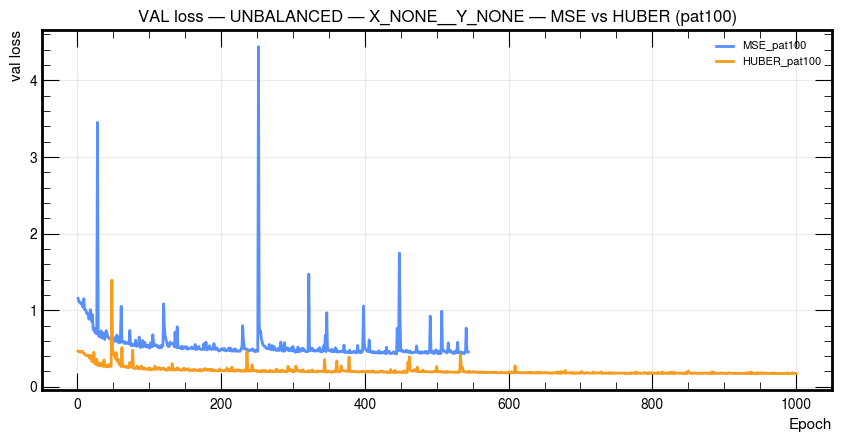

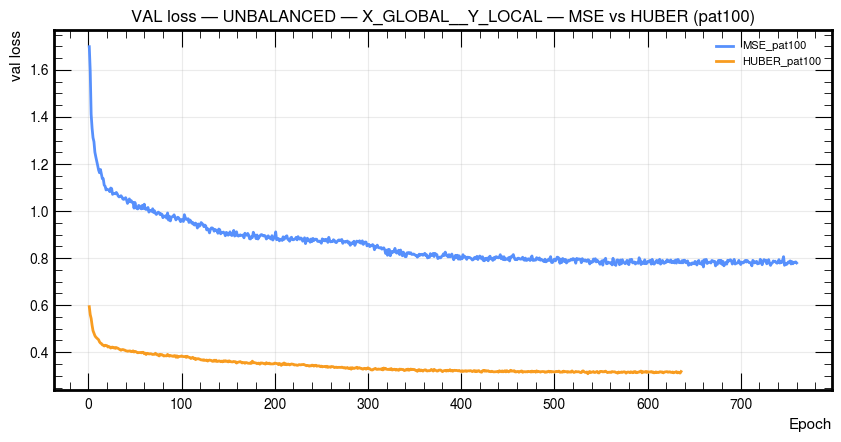

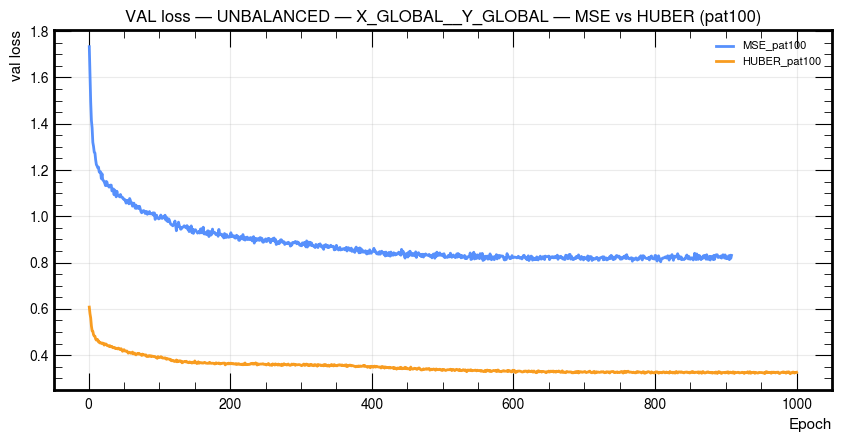

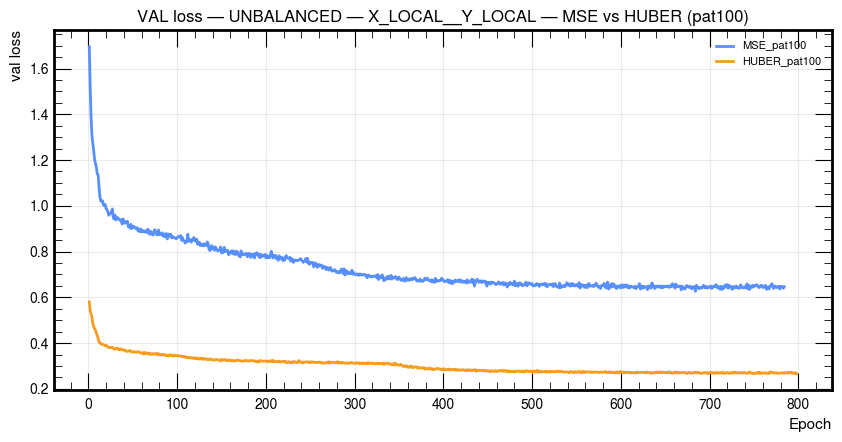

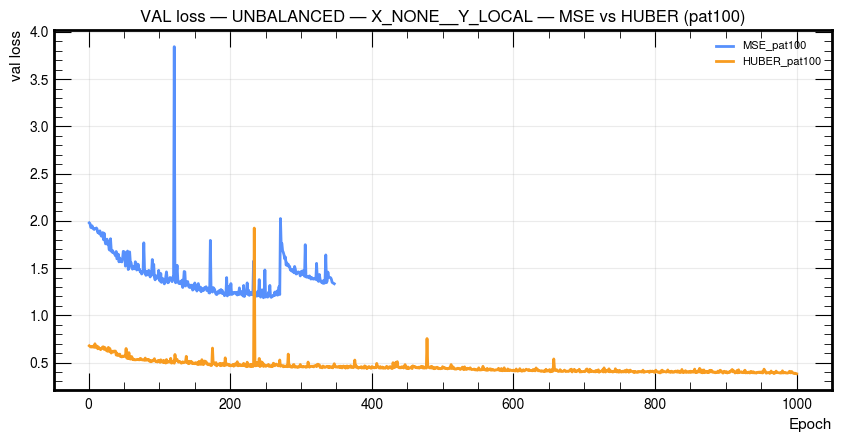

In [ ]:
for mode in SCALING_MODES:

    lossPlots.plot_loss_overlay(
        {
            "MSE_pat30": results_unbalanced_mse_pat30[mode],
            "MSE_pat100": results_unbalanced_mse_pat100[mode],
        },
        title=f"VAL loss — UNBALANCED — {mode} — MSE pat30 vs pat100",
        which="val",
        logy=False,
    )

for mode in SCALING_MODES:

    lossPlots.plot_loss_overlay(
        {
            "HUBER_pat30": results_unbalanced_huber_pat30[mode],
            "HUBER_pat100": results_unbalanced_huber_pat100[mode],
        },
        title=f"VAL loss — UNBALANCED — {mode} — HUBER pat30 vs pat100",
        which="val",
        logy=False,
    )

for mode in SCALING_MODES:

    lossPlots.plot_loss_overlay(
        {
            "MSE_pat30": results_unbalanced_mse_pat30[mode],
            "HUBER_pat30": results_unbalanced_huber_pat30[mode],
        },
        title=f"VAL loss — UNBALANCED — {mode} — MSE vs HUBER (pat30)",
        which="val",
        logy=False,
    )

for mode in SCALING_MODES:

    lossPlots.plot_loss_overlay(
        {
            "MSE_pat100": results_unbalanced_mse_pat100[mode],
            "HUBER_pat100": results_unbalanced_huber_pat100[mode],
        },
        title=f"VAL loss — UNBALANCED — {mode} — MSE vs HUBER (pat100)",
        which="val",
        logy=False,
    )



## Masses
---

### Predictions

In [ ]:
# BALANCED — MSE pat30
preds_bal_mse_pat30 = {}

for mode in SCALING_MODES:
    res = results_balanced_mse_pat30[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_test_bal,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_bal_mse_pat30[mode] = df_pred
    print(mode, "BALANCED MSE pat30 done", df_pred.shape)


# BALANCED — MSE pat100
preds_bal_mse_pat100 = {}

for mode in SCALING_MODES:
    res = results_balanced_mse_pat100[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_test_bal,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_bal_mse_pat100[mode] = df_pred
    print(mode, "BALANCED MSE pat100 done", df_pred.shape)


# BALANCED — HUBER pat30
preds_bal_huber_pat30 = {}

for mode in SCALING_MODES:
    res = results_balanced_huber_pat30[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_test_bal,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_bal_huber_pat30[mode] = df_pred
    print(mode, "BALANCED HUBER pat30 done", df_pred.shape)


# BALANCED — HUBER pat100
preds_bal_huber_pat100 = {}

for mode in SCALING_MODES:
    res = results_balanced_huber_pat100[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_test_bal,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_bal_huber_pat100[mode] = df_pred
    print(mode, "BALANCED HUBER pat100 done", df_pred.shape)

X_NONE__Y_NONE BALANCED MSE pat30 done (16390, 2)
X_GLOBAL__Y_LOCAL BALANCED MSE pat30 done (16390, 2)
X_GLOBAL__Y_GLOBAL BALANCED MSE pat30 done (16390, 2)
X_LOCAL__Y_LOCAL BALANCED MSE pat30 done (16390, 2)
X_NONE__Y_LOCAL BALANCED MSE pat30 done (16390, 2)
X_NONE__Y_NONE BALANCED MSE pat100 done (16390, 2)
X_GLOBAL__Y_LOCAL BALANCED MSE pat100 done (16390, 2)
X_GLOBAL__Y_GLOBAL BALANCED MSE pat100 done (16390, 2)
X_LOCAL__Y_LOCAL BALANCED MSE pat100 done (16390, 2)
X_NONE__Y_LOCAL BALANCED MSE pat100 done (16390, 2)
X_NONE__Y_NONE BALANCED HUBER pat30 done (16390, 2)
X_GLOBAL__Y_LOCAL BALANCED HUBER pat30 done (16390, 2)
X_GLOBAL__Y_GLOBAL BALANCED HUBER pat30 done (16390, 2)
X_LOCAL__Y_LOCAL BALANCED HUBER pat30 done (16390, 2)
X_NONE__Y_LOCAL BALANCED HUBER pat30 done (16390, 2)
X_NONE__Y_NONE BALANCED HUBER pat100 done (16390, 2)
X_GLOBAL__Y_LOCAL BALANCED HUBER pat100 done (16390, 2)
X_GLOBAL__Y_GLOBAL BALANCED HUBER pat100 done (16390, 2)
X_LOCAL__Y_LOCAL BALANCED HUBER pat100 

In [ ]:
# UNBALANCED — MSE pat30
preds_unbal_mse_pat30 = {}

for mode in SCALING_MODES:
    res = results_unbalanced_mse_pat30[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_test_all,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_unbal_mse_pat30[mode] = df_pred
    print(mode, "UNBALANCED MSE pat30 done", df_pred.shape)


# UNBALANCED — MSE pat100
preds_unbal_mse_pat100 = {}

for mode in SCALING_MODES:
    res = results_unbalanced_mse_pat100[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_test_all,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_unbal_mse_pat100[mode] = df_pred
    print(mode, "UNBALANCED MSE pat100 done", df_pred.shape)


# UNBALANCED — HUBER pat30
preds_unbal_huber_pat30 = {}

for mode in SCALING_MODES:
    res = results_unbalanced_huber_pat30[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_test_all,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_unbal_huber_pat30[mode] = df_pred
    print(mode, "UNBALANCED HUBER pat30 done", df_pred.shape)


# UNBALANCED — HUBER pat100
preds_unbal_huber_pat100 = {}

for mode in SCALING_MODES:
    res = results_unbalanced_huber_pat100[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_test_all,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_unbal_huber_pat100[mode] = df_pred
    print(mode, "UNBALANCED HUBER pat100 done", df_pred.shape)

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.
X_NONE__Y_NONE UNBALANCED MSE pat30 done (33736, 2)
X_GLOBAL__Y_LOCAL UNBALANCED MSE pat30 done (33736, 2)
X_GLOBAL__Y_GLOBAL UNBALANCED MSE pat30 done (33736, 2)
X_LOCAL__Y_LOCAL UNBALANCED MSE pat30 done (33736, 2)
X_NONE__Y_LOCAL UNBALANCED MSE pat30 done (33736, 2)
X_NONE__Y_NONE UNBALANCED MSE pat100 done (33736, 2)
X_GLOBAL__Y_LOCAL UNBALANCED MSE pat100 done (33736, 2)
X_GLOBAL__Y_GLOBAL UNBALANCED MSE pat100 done (33736, 2)
X_LOCAL__Y_LOCAL UNBALANCED MSE pat100 done (33736, 2)
X_NONE__Y_LOCAL UNBALANCED MSE pat100 done (33736, 2)
X_NONE__Y_NONE UNBALANCED HUBER pat30 done (33736, 2)
X_GLOBAL__Y_LOCAL UNBALANCED HUBER pat30 done (33736, 2)
X_GLOBAL__Y_GLOBAL UNBALANCED HUBER pat30 done (33736, 2)
X_LOCAL__Y_LOCAL UNBALANCED HUBER pat30 done (33736, 2)
X_NONE__Y_LOCAL UNBALANCED HUBER pat30 done (33736, 2)
X_NONE__Y_NONE UNBALANCED HUB

In [ ]:
preds_bal_mse_pat30["X_NONE__Y_NONE"].head()

,tau1_corr_pred,tau2_corr_pred
0,1.270744,1.029039
1,1.299154,2.294319
2,1.557508,1.287725
3,1.168599,1.335322
4,1.183147,1.332583


### Masses
---

In [ ]:
# BALANCED — MSE pat30
masses_bal_mse_pat30 = {}

for mode in SCALING_MODES:
    
    dfp = preds_bal_mse_pat30[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau1_eta"].to_numpy(),
        df_test_bal["tau1_phi"].to_numpy(),
        df_test_bal["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau2_eta"].to_numpy(),
        df_test_bal["tau2_phi"].to_numpy(),
        df_test_bal["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_bal_mse_pat30[mode] = m
    print(mode, "BALANCED MSE pat30 done:", float(np.mean(m)), float(np.std(m)))


# BALANCED — MSE pat100
masses_bal_mse_pat100 = {}

for mode in SCALING_MODES:
    
    dfp = preds_bal_mse_pat100[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau1_eta"].to_numpy(),
        df_test_bal["tau1_phi"].to_numpy(),
        df_test_bal["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau2_eta"].to_numpy(),
        df_test_bal["tau2_phi"].to_numpy(),
        df_test_bal["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_bal_mse_pat100[mode] = m
    print(mode, "BALANCED MSE pat100 done:", float(np.mean(m)), float(np.std(m)))


# BALANCED — HUBER pat30
masses_bal_huber_pat30 = {}

for mode in SCALING_MODES:
    
    dfp = preds_bal_huber_pat30[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau1_eta"].to_numpy(),
        df_test_bal["tau1_phi"].to_numpy(),
        df_test_bal["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau2_eta"].to_numpy(),
        df_test_bal["tau2_phi"].to_numpy(),
        df_test_bal["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_bal_huber_pat30[mode] = m
    print(mode, "BALANCED HUBER pat30 done:", float(np.mean(m)), float(np.std(m)))


# BALANCED — HUBER pat100
masses_bal_huber_pat100 = {}

for mode in SCALING_MODES:
    
    dfp = preds_bal_huber_pat100[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau1_eta"].to_numpy(),
        df_test_bal["tau1_phi"].to_numpy(),
        df_test_bal["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau2_eta"].to_numpy(),
        df_test_bal["tau2_phi"].to_numpy(),
        df_test_bal["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_bal_huber_pat100[mode] = m
    print(mode, "BALANCED HUBER pat100 done:", float(np.mean(m)), float(np.std(m)))

X_NONE__Y_NONE BALANCED MSE pat30 done: 109.10613953191162 36.28467911926708
X_GLOBAL__Y_LOCAL BALANCED MSE pat30 done: 111.48401770445538 26.52930421605184
X_GLOBAL__Y_GLOBAL BALANCED MSE pat30 done: 110.65094070514492 24.95031763905179
X_LOCAL__Y_LOCAL BALANCED MSE pat30 done: 110.67923900892633 25.800997594161903
X_NONE__Y_LOCAL BALANCED MSE pat30 done: 115.10102746886199 31.266706505966777
X_NONE__Y_NONE BALANCED MSE pat100 done: 111.81414800985799 29.502162266513515
X_GLOBAL__Y_LOCAL BALANCED MSE pat100 done: 111.37130834054474 24.870075733511687
X_GLOBAL__Y_GLOBAL BALANCED MSE pat100 done: 111.53280327674109 24.72100965309178
X_LOCAL__Y_LOCAL BALANCED MSE pat100 done: 110.1978917487911 25.170910728245918
X_NONE__Y_LOCAL BALANCED MSE pat100 done: 114.45422503479814 29.984466949926876
X_NONE__Y_NONE BALANCED HUBER pat30 done: 108.65623197064022 31.586616416140888
X_GLOBAL__Y_LOCAL BALANCED HUBER pat30 done: 108.81022728865794 21.881084180690063
X_GLOBAL__Y_GLOBAL BALANCED HUBER pat

In [ ]:
# UNBALANCED — MSE pat30
masses_unbal_mse_pat30 = {}

for mode in SCALING_MODES:
    
    dfp = preds_unbal_mse_pat30[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_all["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau1_eta"].to_numpy(),
        df_test_all["tau1_phi"].to_numpy(),
        df_test_all["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_all["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau2_eta"].to_numpy(),
        df_test_all["tau2_phi"].to_numpy(),
        df_test_all["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_unbal_mse_pat30[mode] = m
    print(mode, "UNBALANCED MSE pat30 done:", float(np.mean(m)), float(np.std(m)))


# UNBALANCED — MSE pat100
masses_unbal_mse_pat100 = {}

for mode in SCALING_MODES:
    
    dfp = preds_unbal_mse_pat100[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_all["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau1_eta"].to_numpy(),
        df_test_all["tau1_phi"].to_numpy(),
        df_test_all["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_all["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau2_eta"].to_numpy(),
        df_test_all["tau2_phi"].to_numpy(),
        df_test_all["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_unbal_mse_pat100[mode] = m
    print(mode, "UNBALANCED MSE pat100 done:", float(np.mean(m)), float(np.std(m)))


# UNBALANCED — HUBER pat30
masses_unbal_huber_pat30 = {}

for mode in SCALING_MODES:
    
    dfp = preds_unbal_huber_pat30[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_all["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau1_eta"].to_numpy(),
        df_test_all["tau1_phi"].to_numpy(),
        df_test_all["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_all["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau2_eta"].to_numpy(),
        df_test_all["tau2_phi"].to_numpy(),
        df_test_all["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_unbal_huber_pat30[mode] = m
    print(mode, "UNBALANCED HUBER pat30 done:", float(np.mean(m)), float(np.std(m)))


# UNBALANCED — HUBER pat100
masses_unbal_huber_pat100 = {}

for mode in SCALING_MODES:
    
    dfp = preds_unbal_huber_pat100[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_all["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau1_eta"].to_numpy(),
        df_test_all["tau1_phi"].to_numpy(),
        df_test_all["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_all["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau2_eta"].to_numpy(),
        df_test_all["tau2_phi"].to_numpy(),
        df_test_all["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_unbal_huber_pat100[mode] = m
    print(mode, "UNBALANCED HUBER pat100 done:", float(np.mean(m)), float(np.std(m)))

X_NONE__Y_NONE UNBALANCED MSE pat30 done: 122.34191983547026 33.94584814464045
X_GLOBAL__Y_LOCAL UNBALANCED MSE pat30 done: 117.68056376235744 18.992709753576122
X_GLOBAL__Y_GLOBAL UNBALANCED MSE pat30 done: 117.5773994274409 17.693087233152266
X_LOCAL__Y_LOCAL UNBALANCED MSE pat30 done: 117.60195970679469 17.264250113820445
X_NONE__Y_LOCAL UNBALANCED MSE pat30 done: 118.75406930954374 23.86431707626487
X_NONE__Y_NONE UNBALANCED MSE pat100 done: 120.20757133634348 23.823789345783695
X_GLOBAL__Y_LOCAL UNBALANCED MSE pat100 done: 116.9191053257112 16.767661757982456
X_GLOBAL__Y_GLOBAL UNBALANCED MSE pat100 done: 117.60300181526664 16.961535255910558
X_LOCAL__Y_LOCAL UNBALANCED MSE pat100 done: 117.82058622804936 17.39945224392962
X_NONE__Y_LOCAL UNBALANCED MSE pat100 done: 118.06014534762961 22.025551879018433
X_NONE__Y_NONE UNBALANCED HUBER pat30 done: 116.54087817203101 22.160651516084496
X_GLOBAL__Y_LOCAL UNBALANCED HUBER pat30 done: 117.127708350418 18.058144798299672
X_GLOBAL__Y_GLO

In [ ]:
# check
for mode in SCALING_MODES:
    print(
        mode,
        len(masses_bal_mse_pat30[mode]), len(df_test_bal),
        len(masses_unbal_mse_pat30[mode]), len(df_test_all)
    )

X_NONE__Y_NONE 16390 16390 33736 33736
X_GLOBAL__Y_LOCAL 16390 16390 33736 33736
X_GLOBAL__Y_GLOBAL 16390 16390 33736 33736
X_LOCAL__Y_LOCAL 16390 16390 33736 33736
X_NONE__Y_LOCAL 16390 16390 33736 33736


### Saving the Masses
---

In [ ]:
OUT = "../results/masses"
os.makedirs(OUT, exist_ok=True)

In [34]:
# Salvataggio masse con compressione

np.savez_compressed(
    os.path.join(OUT, "masses_bal_nonflat_mse_pat30.npz"),
    **masses_bal_mse_pat30
)

np.savez_compressed(
    os.path.join(OUT, "masses_bal_nonflat_mse_pat100.npz"),
    **masses_bal_mse_pat100
)

np.savez_compressed(
    os.path.join(OUT, "masses_bal_nonflat_huber_d1_pat30.npz"),
    **masses_bal_huber_pat30
)

np.savez_compressed(
    os.path.join(OUT, "masses_bal_nonflat_huber_d1_pat100.npz"),
    **masses_bal_huber_pat100
)

np.savez_compressed(
    os.path.join(OUT, "masses_unbal_nonflat_mse_pat30.npz"),
    **masses_unbal_mse_pat30
)

np.savez_compressed(
    os.path.join(OUT, "masses_unbal_nonflat_mse_pat100.npz"),
    **masses_unbal_mse_pat100
)

np.savez_compressed(
    os.path.join(OUT, "masses_unbal_nonflat_huber_d1_pat30.npz"),
    **masses_unbal_huber_pat30
)

np.savez_compressed(
    os.path.join(OUT, "masses_unbal_nonflat_huber_d1_pat100.npz"),
    **masses_unbal_huber_pat100
)

In [35]:
# check 

print(os.listdir(OUT))

['masses_unbal_nonflat_mse_dy.npz', 'masses_bal_nonflat_huber_d1_pat30.npz', 'masses_bal_nonflat_mse_pat100.npz', 'masses_bal_nonflat_mse_dy.npz', 'masses_unbal_nonflat_mse_dy_pat100.npz', 'masses_bal_nonflat_mse_h_pat100.npz', 'masses_bal_nonflat_mse_dy_pat100.npz', 'masses_bal_nonflat_mse_verified.npz', 'masses_bal_mse.npz', 'masses_bal_nonflat_huber_d1_pat100.npz', 'masses_unbal_nonflat_mse_h.npz', 'masses_bal_nonflat_mse_pat30.npz', 'masses_unbal_nonflat_huber_d1_pat100.npz', 'masses_unbal_nonflat_mse_pat30.npz', 'masses_bal_nonflat_mse_h.npz', 'masses_unbal_nonflat_mse_h_pat100.npz', 'masses_unbal_nonflat_mse_verified.npz', 'masses_unbal_mse.npz', 'masses_unbal_nonflat_mse_pat100.npz', 'masses_unbal_nonflat_huber_d1_pat30.npz']


In [36]:
# check 2
test = np.load(os.path.join(OUT, "masses_bal_nonflat_mse_pat30.npz"))
print(test.files)

['X_NONE__Y_NONE', 'X_GLOBAL__Y_LOCAL', 'X_GLOBAL__Y_GLOBAL', 'X_LOCAL__Y_LOCAL', 'X_NONE__Y_LOCAL']


### Plot the Masses
---

In [37]:
# Separo per classe:
m_dy_bal = (df_test_bal["class"].to_numpy() == 0)
m_h_bal  = (df_test_bal["class"].to_numpy() == 1)

m_dy_unb = (df_test_all["class"].to_numpy() == 0)
m_h_unb  = (df_test_all["class"].to_numpy() == 1)

In [38]:
# Dizionari separati per classe:
# BALANCED — MSE pat30
masses_bal_dy_mse_pat30 = {
    mode: np.asarray(masses_bal_mse_pat30[mode])[m_dy_bal]
    for mode in SCALING_MODES
}
masses_bal_h_mse_pat30 = {
    mode: np.asarray(masses_bal_mse_pat30[mode])[m_h_bal]
    for mode in SCALING_MODES
}

# BALANCED — MSE pat100
masses_bal_dy_mse_pat100 = {
    mode: np.asarray(masses_bal_mse_pat100[mode])[m_dy_bal]
    for mode in SCALING_MODES
}
masses_bal_h_mse_pat100 = {
    mode: np.asarray(masses_bal_mse_pat100[mode])[m_h_bal]
    for mode in SCALING_MODES
}

# BALANCED — HUBER pat30
masses_bal_dy_huber_pat30 = {
    mode: np.asarray(masses_bal_huber_pat30[mode])[m_dy_bal]
    for mode in SCALING_MODES
}
masses_bal_h_huber_pat30 = {
    mode: np.asarray(masses_bal_huber_pat30[mode])[m_h_bal]
    for mode in SCALING_MODES
}

# BALANCED — HUBER pat100
masses_bal_dy_huber_pat100 = {
    mode: np.asarray(masses_bal_huber_pat100[mode])[m_dy_bal]
    for mode in SCALING_MODES
}
masses_bal_h_huber_pat100 = {
    mode: np.asarray(masses_bal_huber_pat100[mode])[m_h_bal]
    for mode in SCALING_MODES
}

# UNBALANCED — MSE pat30
masses_unb_dy_mse_pat30 = {
    mode: np.asarray(masses_unbal_mse_pat30[mode])[m_dy_unb]
    for mode in SCALING_MODES
}
masses_unb_h_mse_pat30 = {
    mode: np.asarray(masses_unbal_mse_pat30[mode])[m_h_unb]
    for mode in SCALING_MODES
}

# UNBALANCED — MSE pat100
masses_unb_dy_mse_pat100 = {
    mode: np.asarray(masses_unbal_mse_pat100[mode])[m_dy_unb]
    for mode in SCALING_MODES
}
masses_unb_h_mse_pat100 = {
    mode: np.asarray(masses_unbal_mse_pat100[mode])[m_h_unb]
    for mode in SCALING_MODES
}

# UNBALANCED — HUBER pat30
masses_unb_dy_huber_pat30 = {
    mode: np.asarray(masses_unbal_huber_pat30[mode])[m_dy_unb]
    for mode in SCALING_MODES
}
masses_unb_h_huber_pat30 = {
    mode: np.asarray(masses_unbal_huber_pat30[mode])[m_h_unb]
    for mode in SCALING_MODES
}

# UNBALANCED — HUBER pat100
masses_unb_dy_huber_pat100 = {
    mode: np.asarray(masses_unbal_huber_pat100[mode])[m_dy_unb]
    for mode in SCALING_MODES
}
masses_unb_h_huber_pat100 = {
    mode: np.asarray(masses_unbal_huber_pat100[mode])[m_h_unb]
    for mode in SCALING_MODES
}

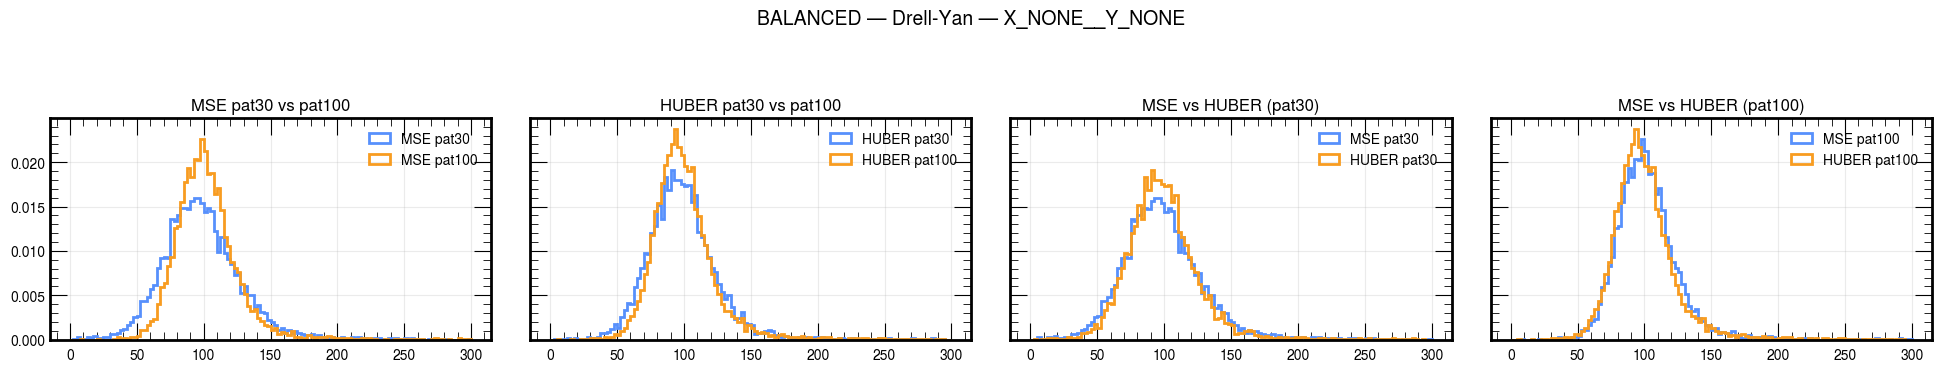

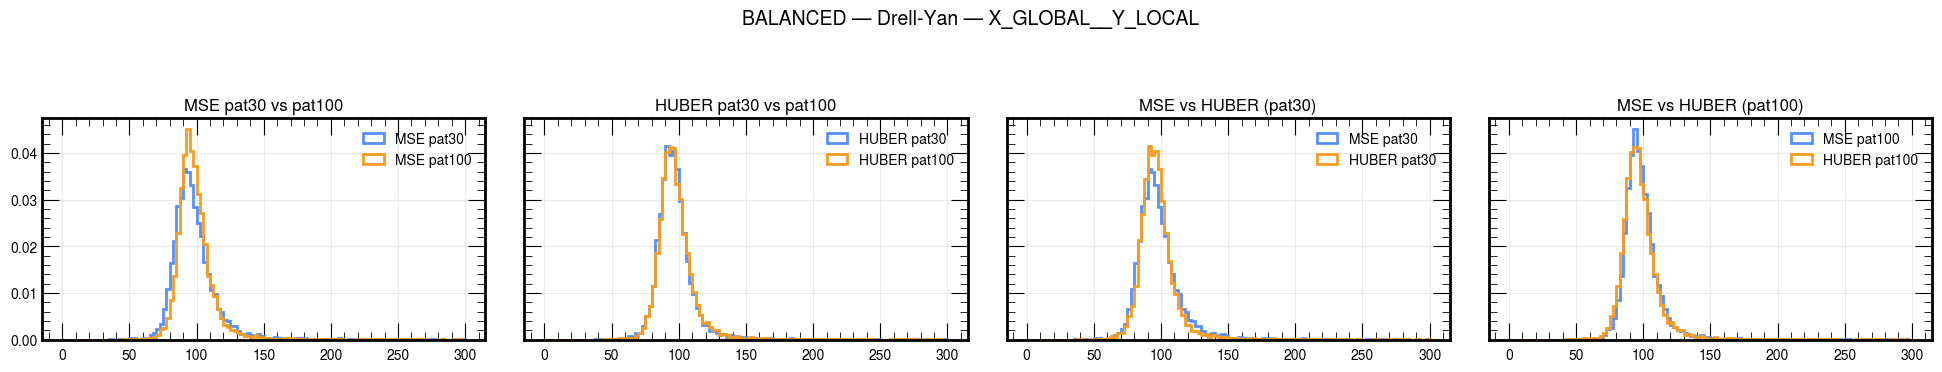

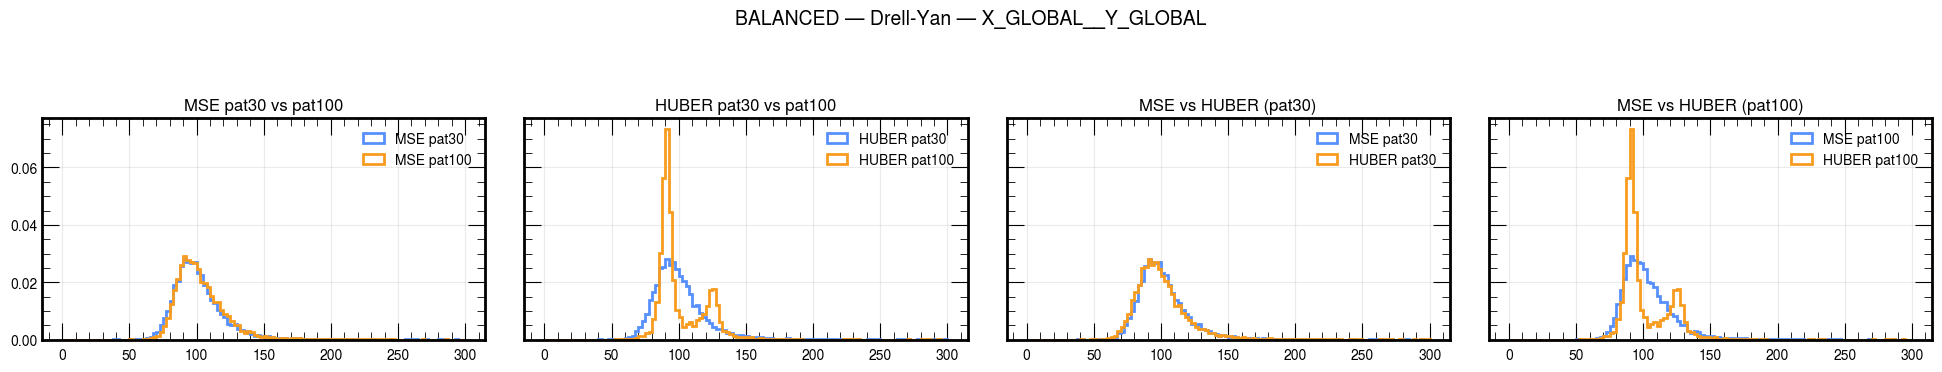

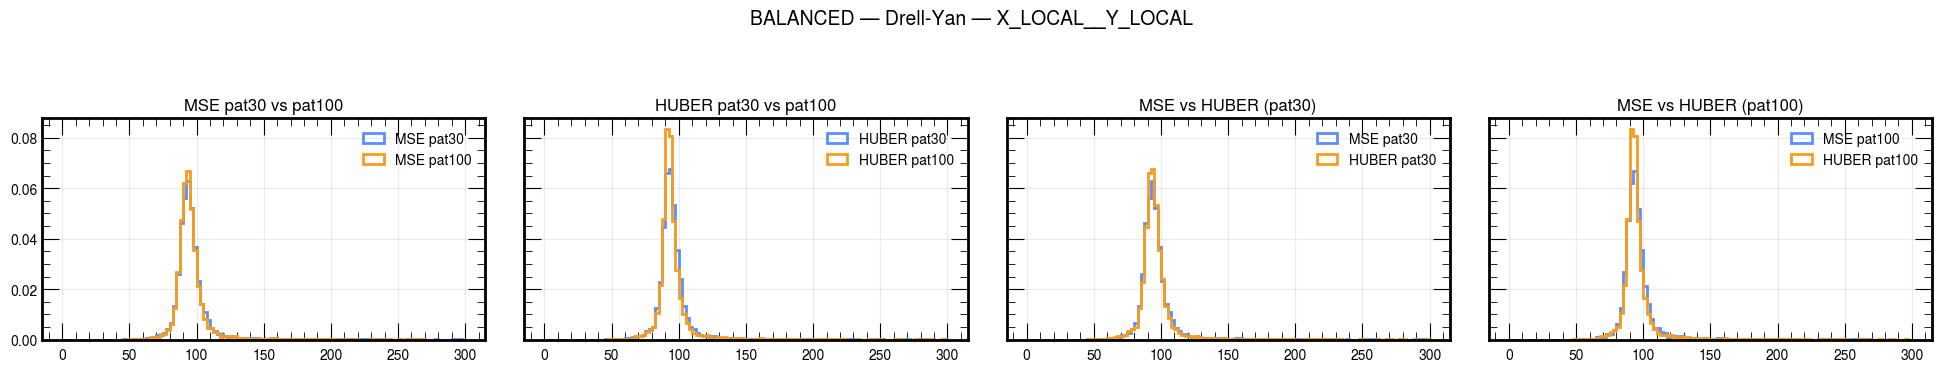

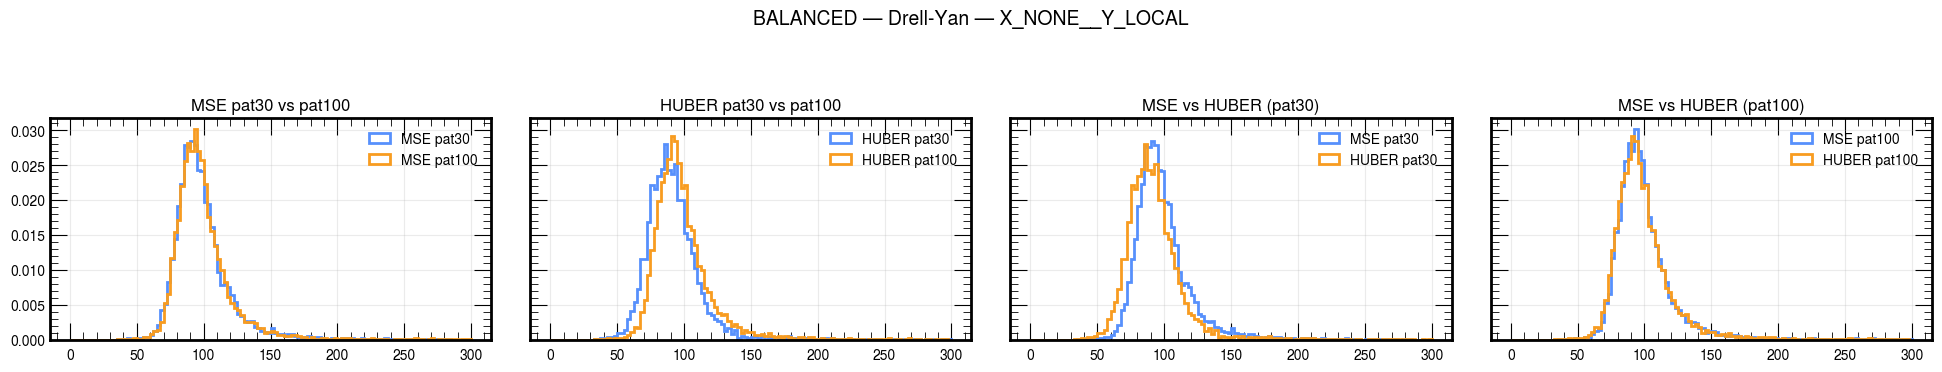

In [39]:
for mode in SCALING_MODES:

    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

    # MSE pat30 vs pat100
    axes[0].hist(
        masses_bal_dy_mse_pat30[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="MSE pat30",
    )

    axes[0].hist(
        masses_bal_dy_mse_pat100[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="MSE pat100",
    )

    axes[0].set_title("MSE pat30 vs pat100")
    axes[0].legend()


    # HUBER pat30 vs pat100
    axes[1].hist(
        masses_bal_dy_huber_pat30[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="HUBER pat30",
    )

    axes[1].hist(
        masses_bal_dy_huber_pat100[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="HUBER pat100",
    )

    axes[1].set_title("HUBER pat30 vs pat100")
    axes[1].legend()


    # MSE vs HUBER pat30
    axes[2].hist(
        masses_bal_dy_mse_pat30[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="MSE pat30",
    )

    axes[2].hist(
        masses_bal_dy_huber_pat30[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="HUBER pat30",
    )

    axes[2].set_title("MSE vs HUBER (pat30)")
    axes[2].legend()


    # MSE vs HUBER pat100
    axes[3].hist(
        masses_bal_dy_mse_pat100[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="MSE pat100",
    )

    axes[3].hist(
        masses_bal_dy_huber_pat100[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="HUBER pat100",
    )

    axes[3].set_title("MSE vs HUBER (pat100)")
    axes[3].legend()


    fig.suptitle(f"BALANCED — Drell-Yan — {mode}", fontsize=14)

    plt.tight_layout()
    plt.show()

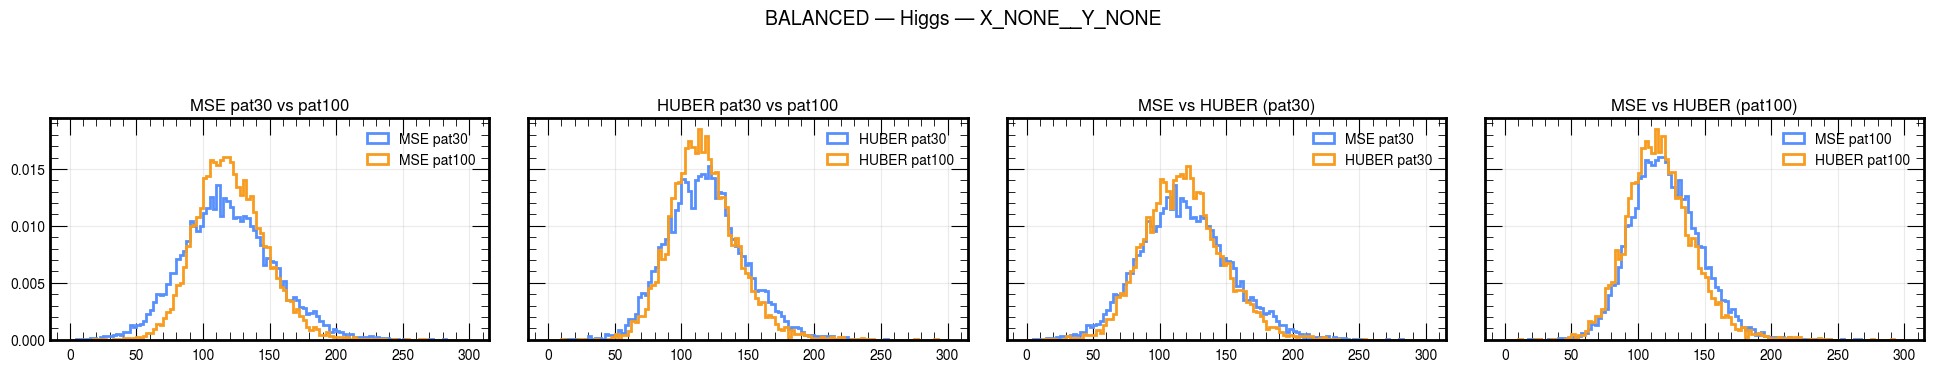

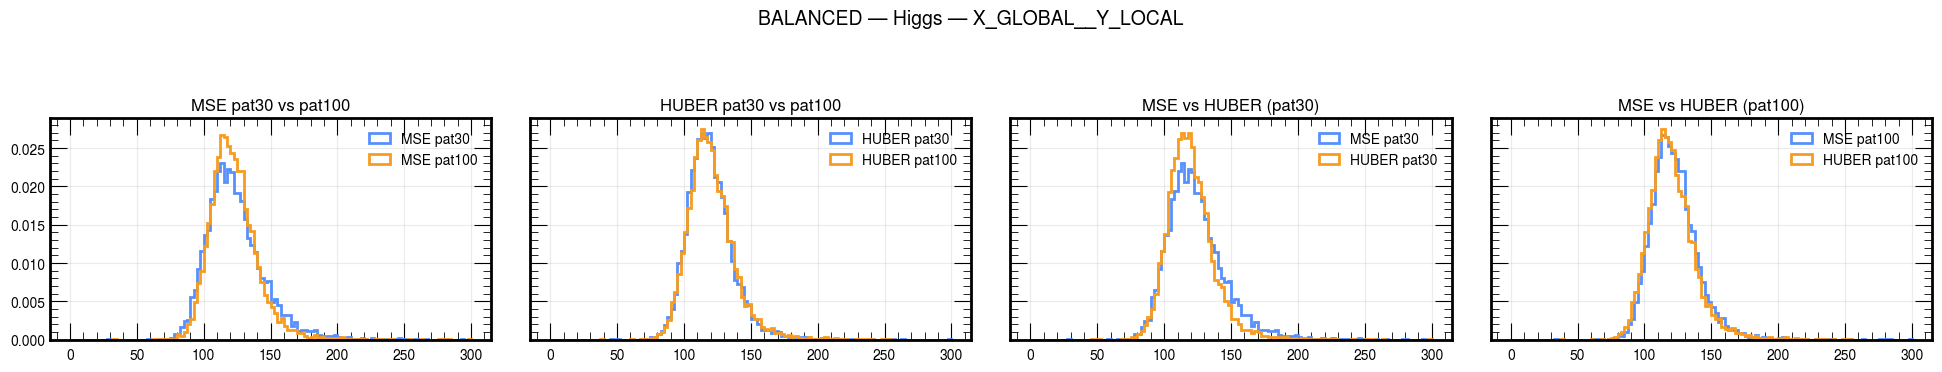

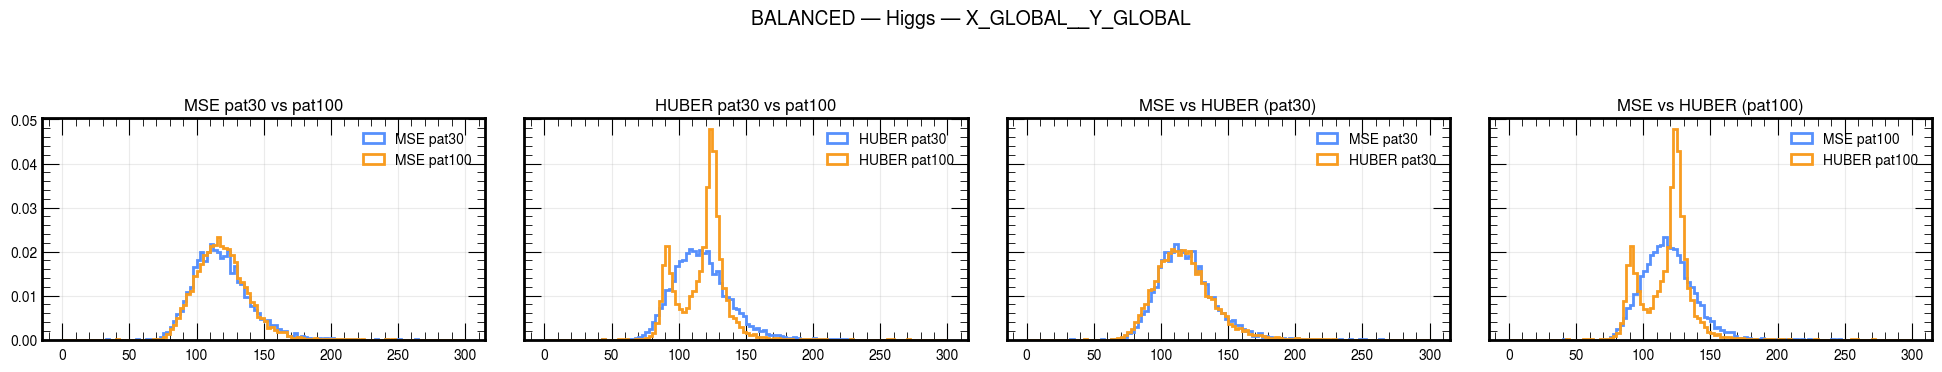

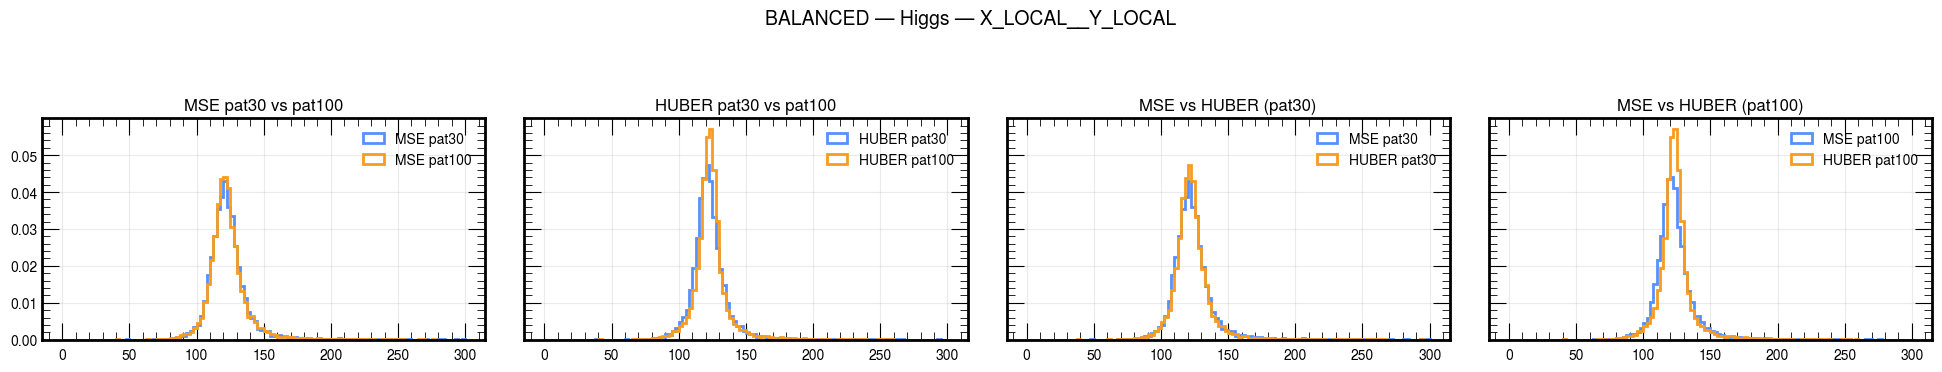

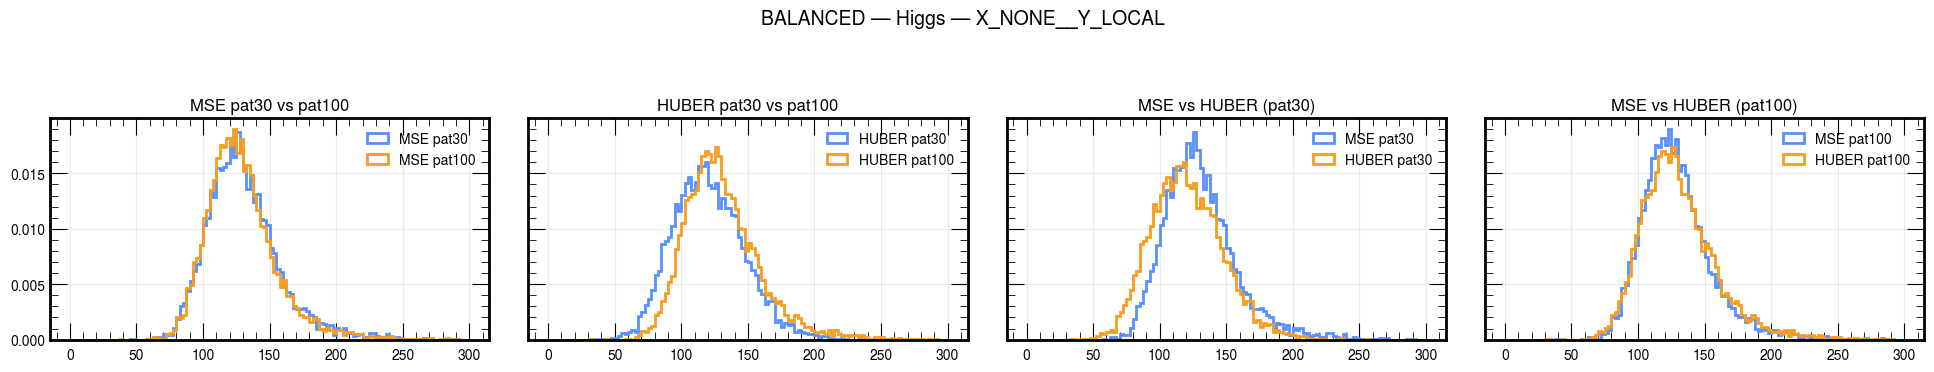

In [46]:
common_range = (0, 300)

for mode in SCALING_MODES:

    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

    # MSE pat30 vs pat100
    axes[0].hist(
        masses_bal_h_mse_pat30[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="MSE pat30",
    )

    axes[0].hist(
        masses_bal_h_mse_pat100[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="MSE pat100",
    )

    axes[0].set_title("MSE pat30 vs pat100")
    axes[0].legend()


    # HUBER pat30 vs pat100
    axes[1].hist(
        masses_bal_h_huber_pat30[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="HUBER pat30",
    )

    axes[1].hist(
        masses_bal_h_huber_pat100[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="HUBER pat100",
    )

    axes[1].set_title("HUBER pat30 vs pat100")
    axes[1].legend()


    # MSE vs HUBER pat30
    axes[2].hist(
        masses_bal_h_mse_pat30[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="MSE pat30",
    )

    axes[2].hist(
        masses_bal_h_huber_pat30[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="HUBER pat30",
    )

    axes[2].set_title("MSE vs HUBER (pat30)")
    axes[2].legend()


    # MSE vs HUBER pat100
    axes[3].hist(
        masses_bal_h_mse_pat100[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="MSE pat100",
    )

    axes[3].hist(
        masses_bal_h_huber_pat100[mode],
        bins=120,
        range=common_range,
        density=True,
        histtype="step",
        linewidth=2,
        label="HUBER pat100",
    )

    axes[3].set_title("MSE vs HUBER (pat100)")
    axes[3].legend()

    fig.suptitle(f"BALANCED — Higgs — {mode}", fontsize=14)

    plt.tight_layout()
    plt.show()

In [41]:
import importlib
import fm.massesPlots as massesPlots
importlib.reload(massesPlots)

<module 'fm.massesPlots' from '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/fm/massesPlots.py'>

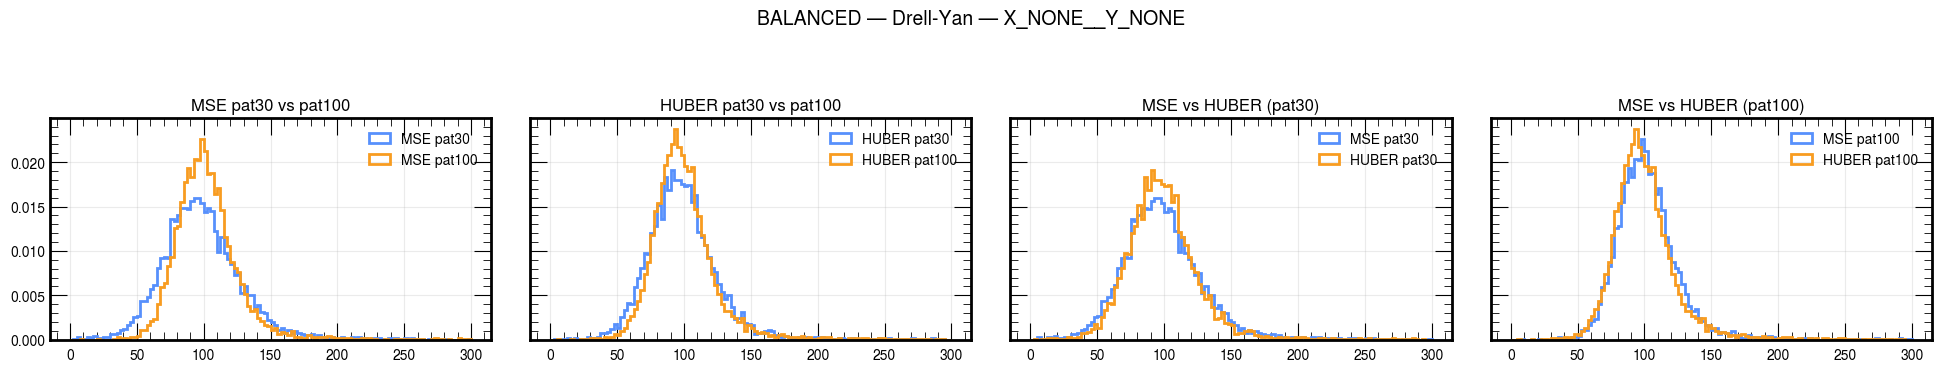

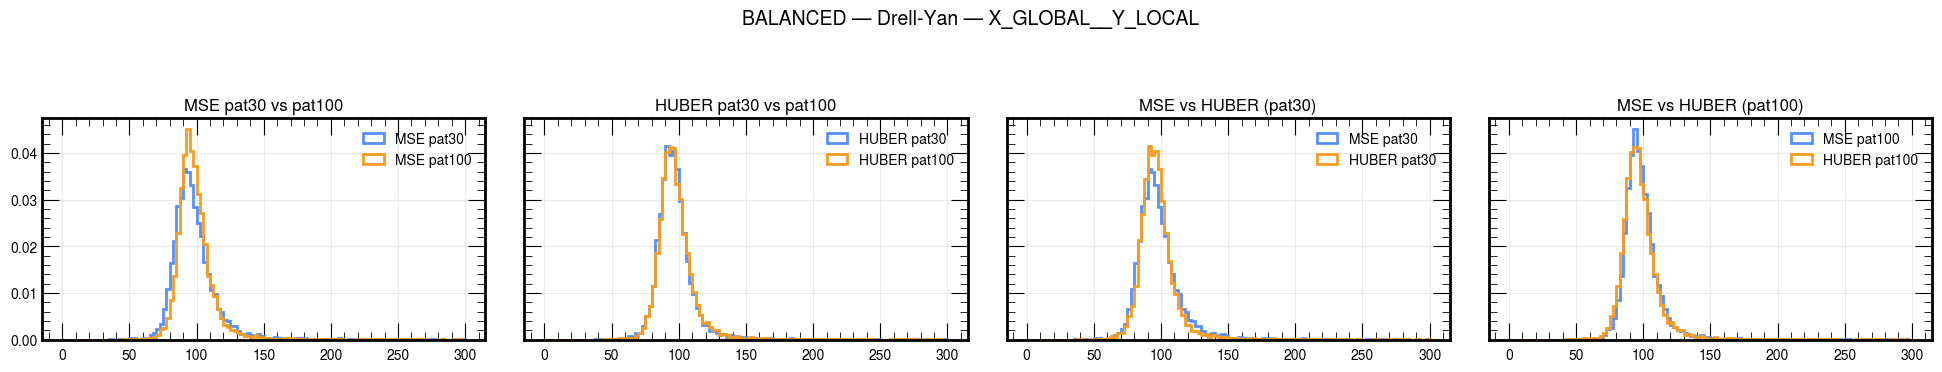

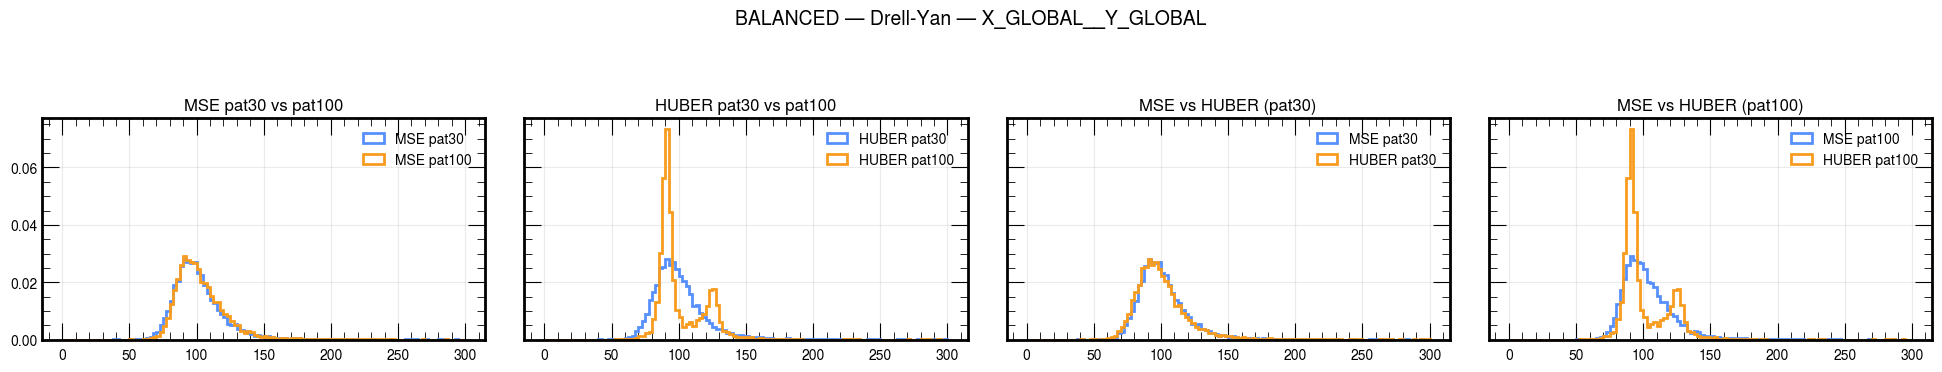

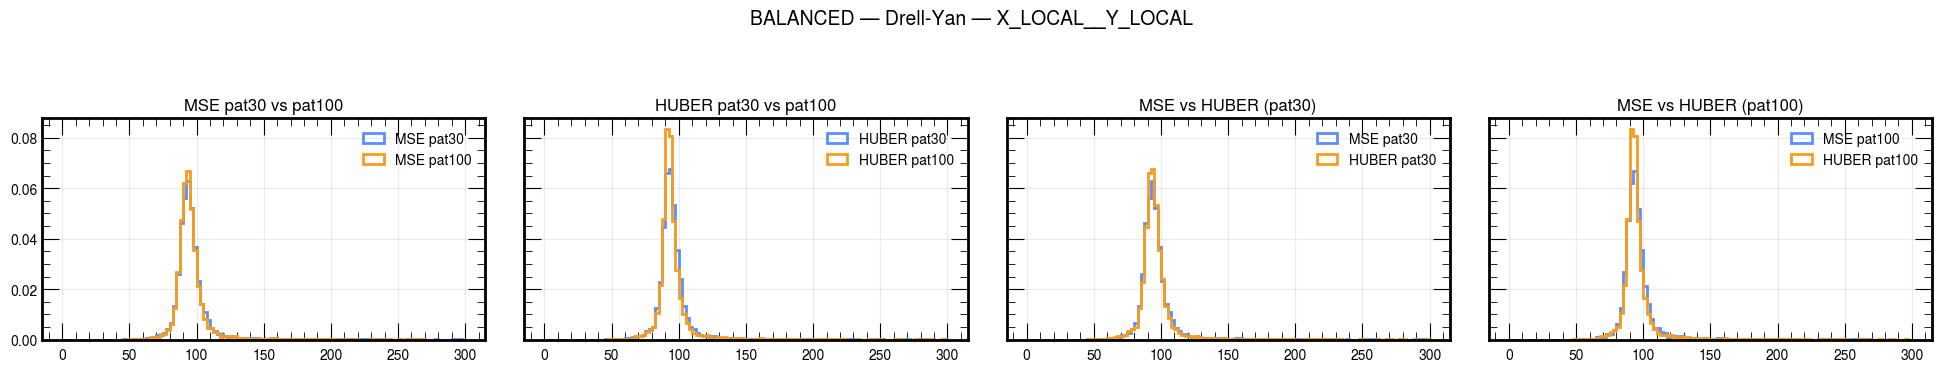

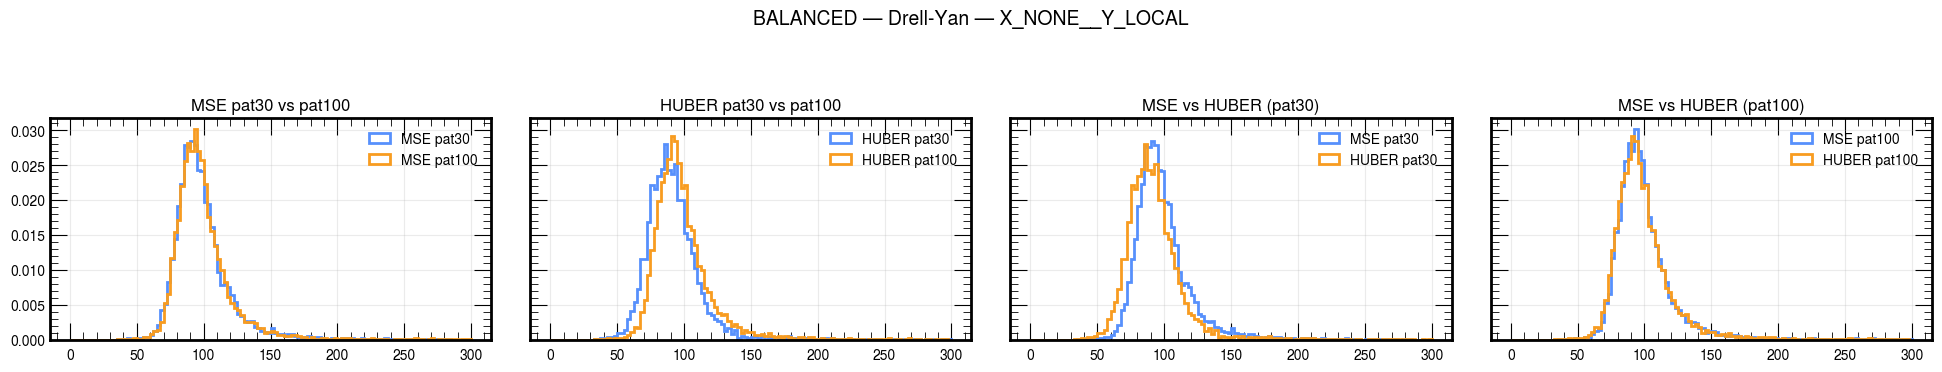

In [43]:
massesPlots.plot_mass_grid_by_mode(
    masses_a_pat30=masses_bal_dy_mse_pat30,
    masses_a_pat100=masses_bal_dy_mse_pat100,
    masses_b_pat30=masses_bal_dy_huber_pat30,
    masses_b_pat100=masses_bal_dy_huber_pat100,
    scaling_modes=SCALING_MODES,
    main_title="BALANCED — Drell-Yan",
    label_a="MSE",
    label_b="HUBER",
    bins=120,
    range_=(0, 300),
    density=True,
    add_higgs_line=False,
)

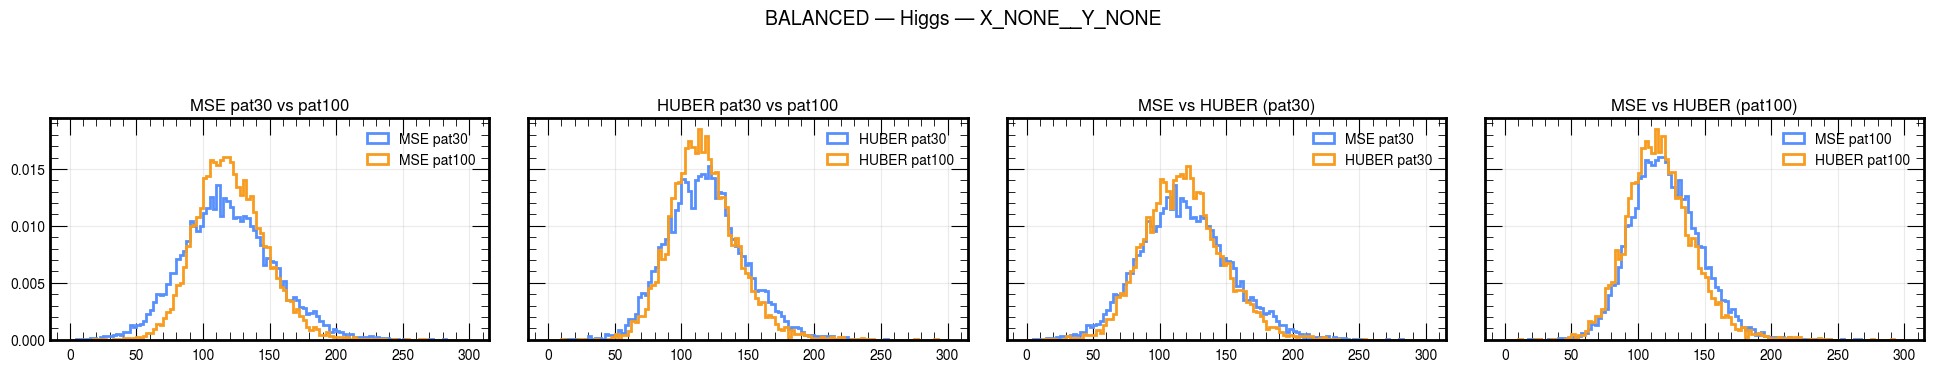

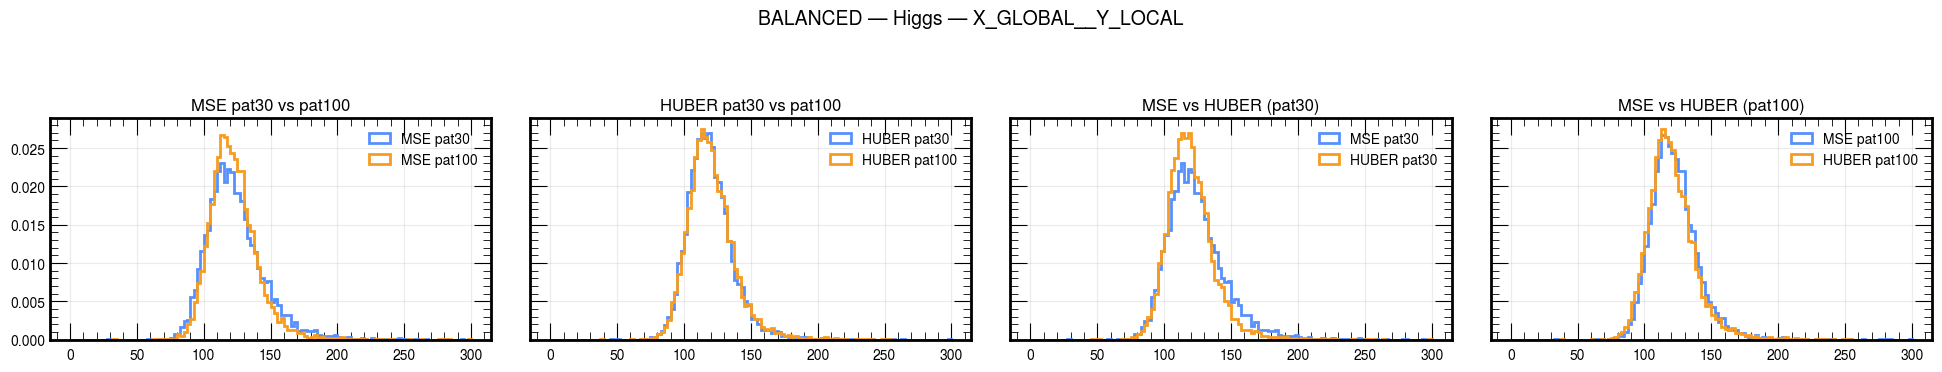

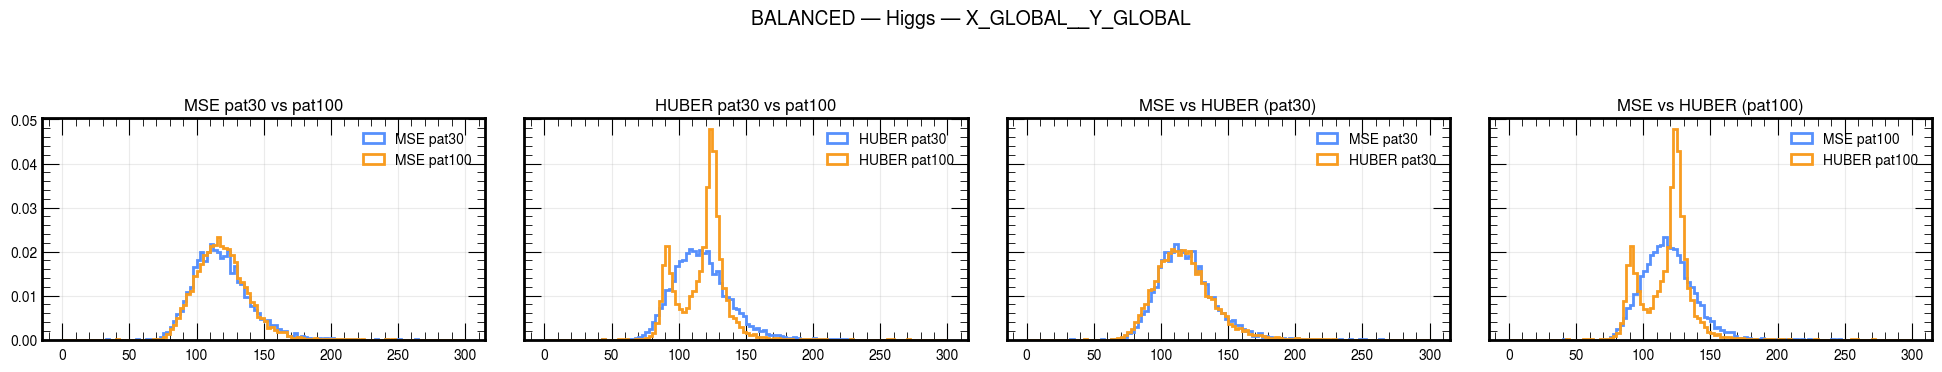

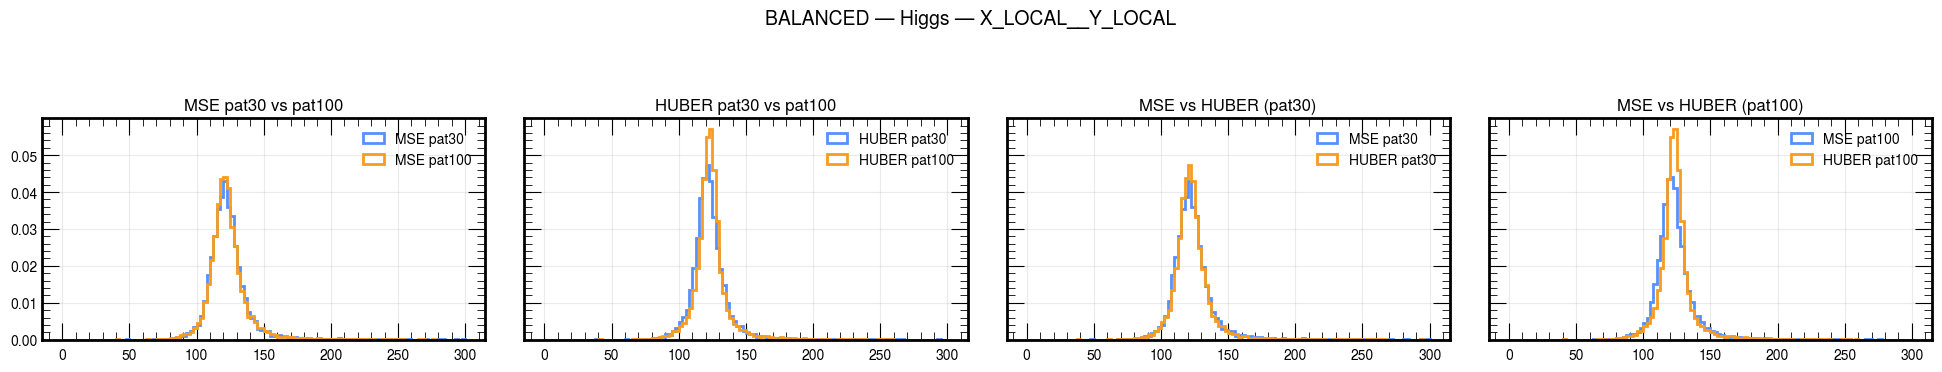

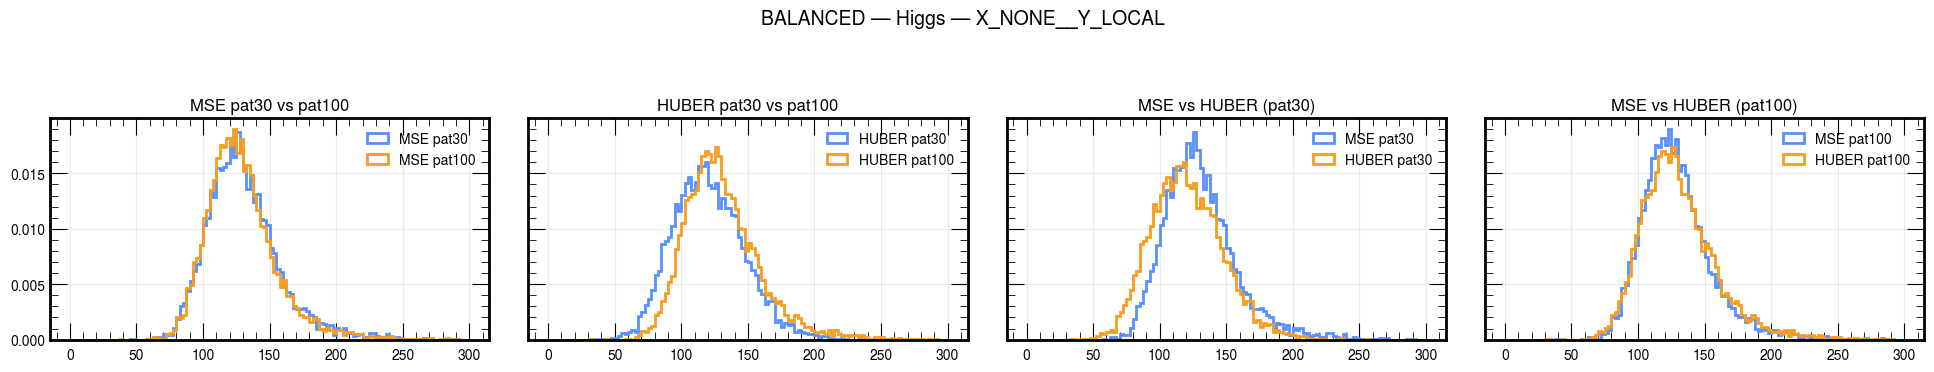

In [45]:
massesPlots.plot_mass_grid_by_mode(
    masses_a_pat30=masses_bal_h_mse_pat30,
    masses_a_pat100=masses_bal_h_mse_pat100,
    masses_b_pat30=masses_bal_h_huber_pat30,
    masses_b_pat100=masses_bal_h_huber_pat100,
    scaling_modes=SCALING_MODES,
    main_title="BALANCED — Higgs",
    label_a="MSE",
    label_b="HUBER",
    bins=120,
    range_=(0, 300),
    density=True,
    add_higgs_line=False,
)

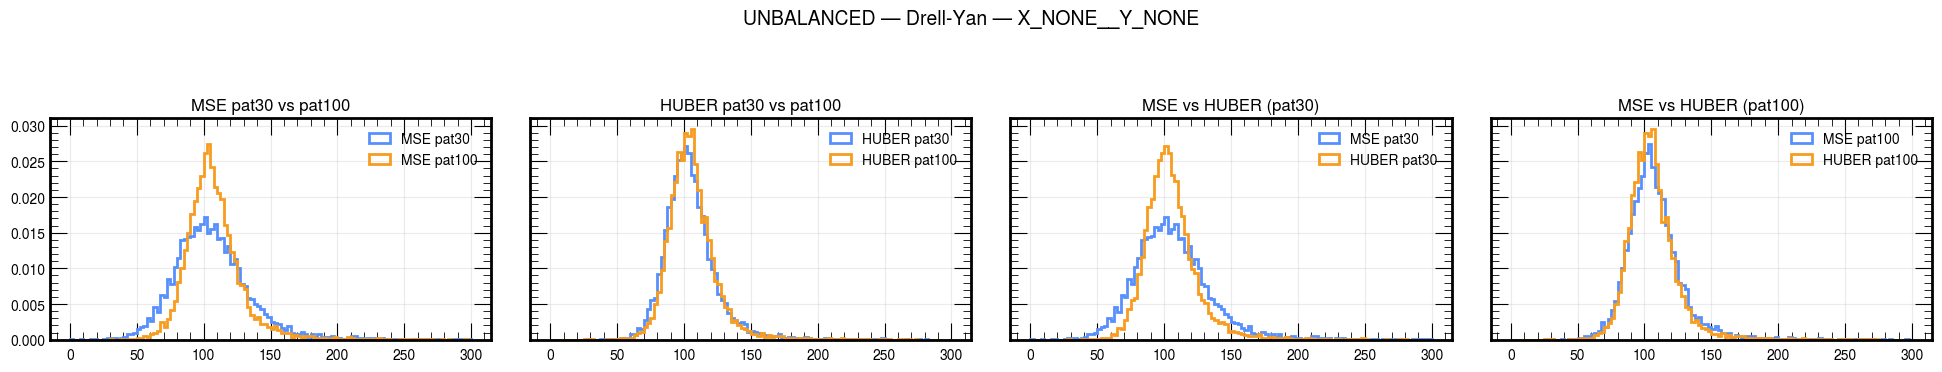

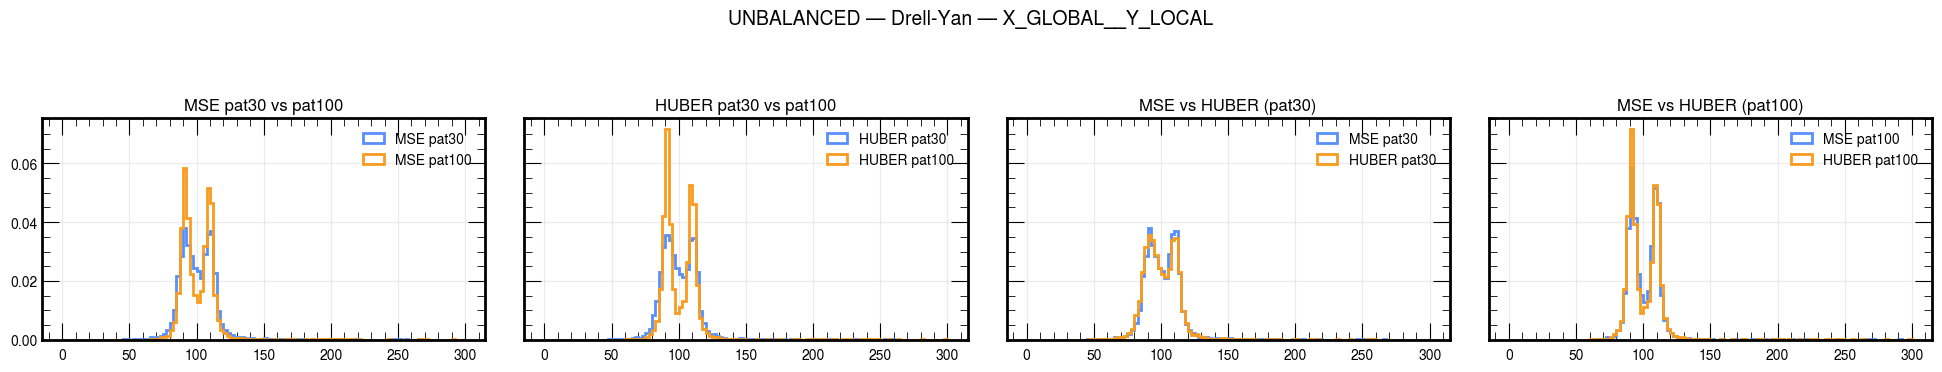

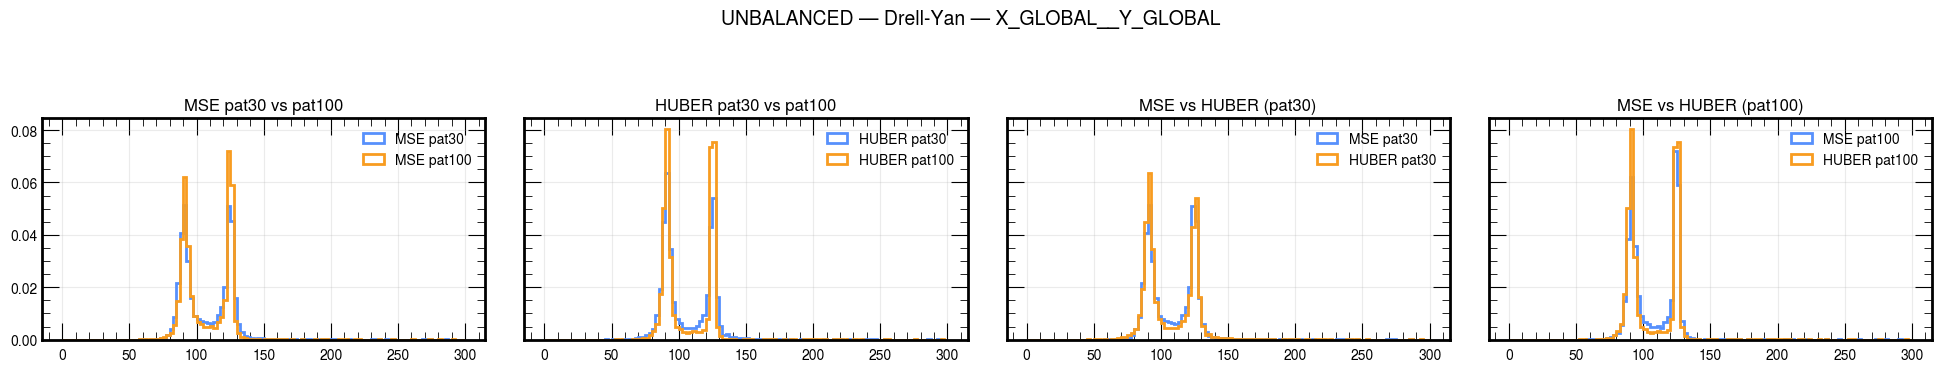

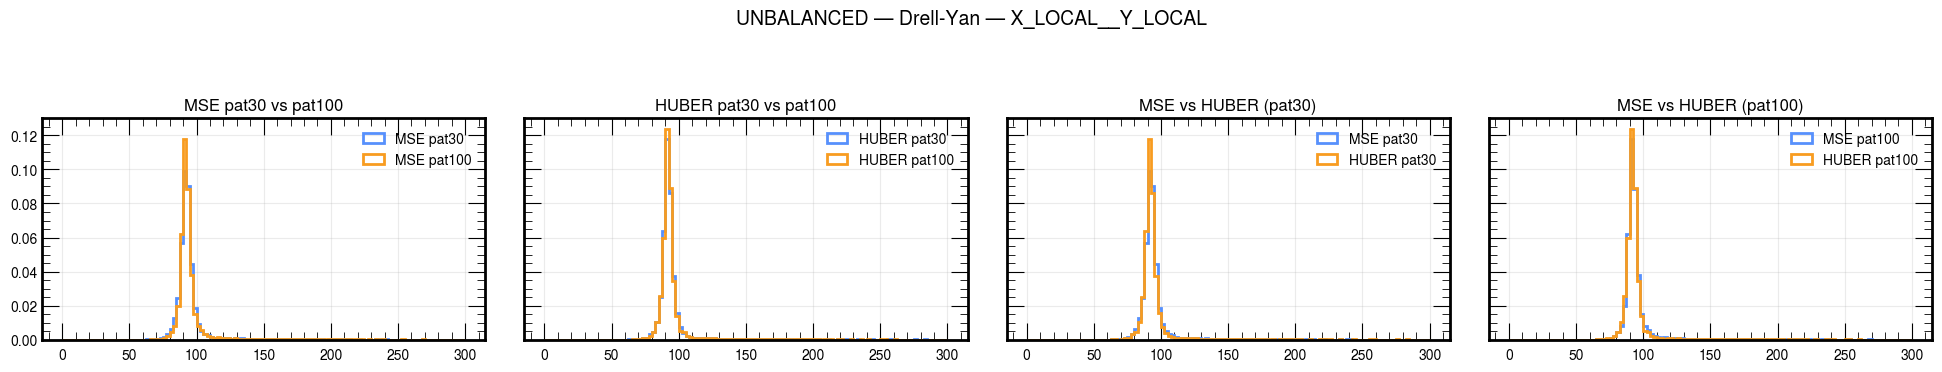

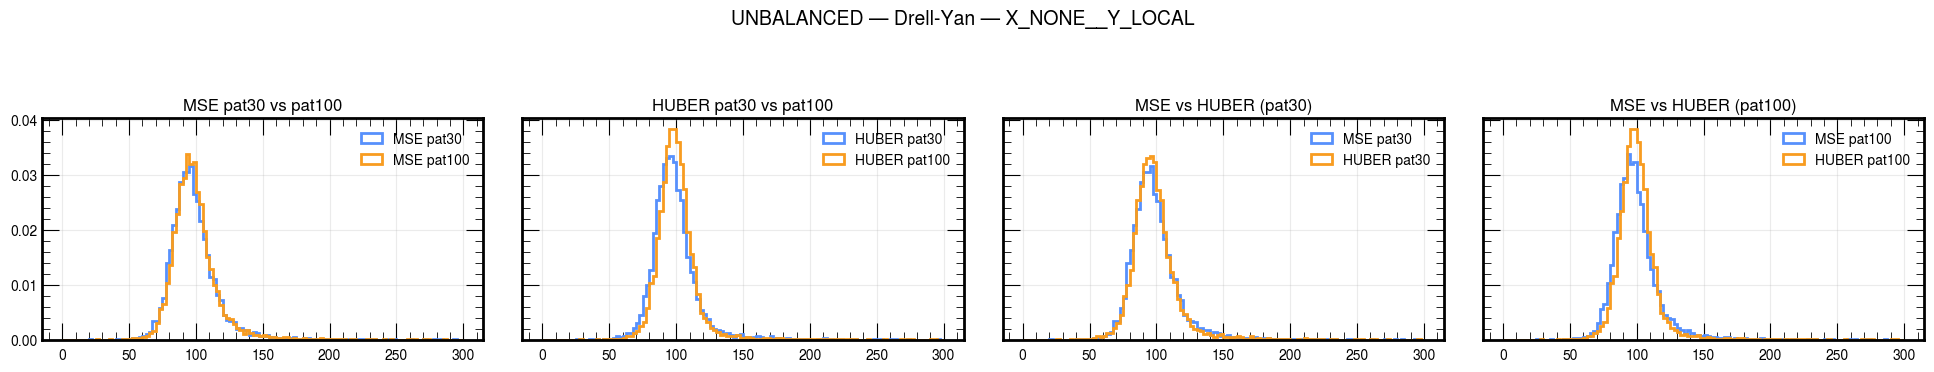

In [47]:
massesPlots.plot_mass_grid_by_mode(
    masses_a_pat30=masses_unb_dy_mse_pat30,
    masses_a_pat100=masses_unb_dy_mse_pat100,
    masses_b_pat30=masses_unb_dy_huber_pat30,
    masses_b_pat100=masses_unb_dy_huber_pat100,
    scaling_modes=SCALING_MODES,
    main_title="UNBALANCED — Drell-Yan",
    label_a="MSE",
    label_b="HUBER",
    bins=120,
    range_=(0, 300),
    density=True,
    add_higgs_line=False,
)

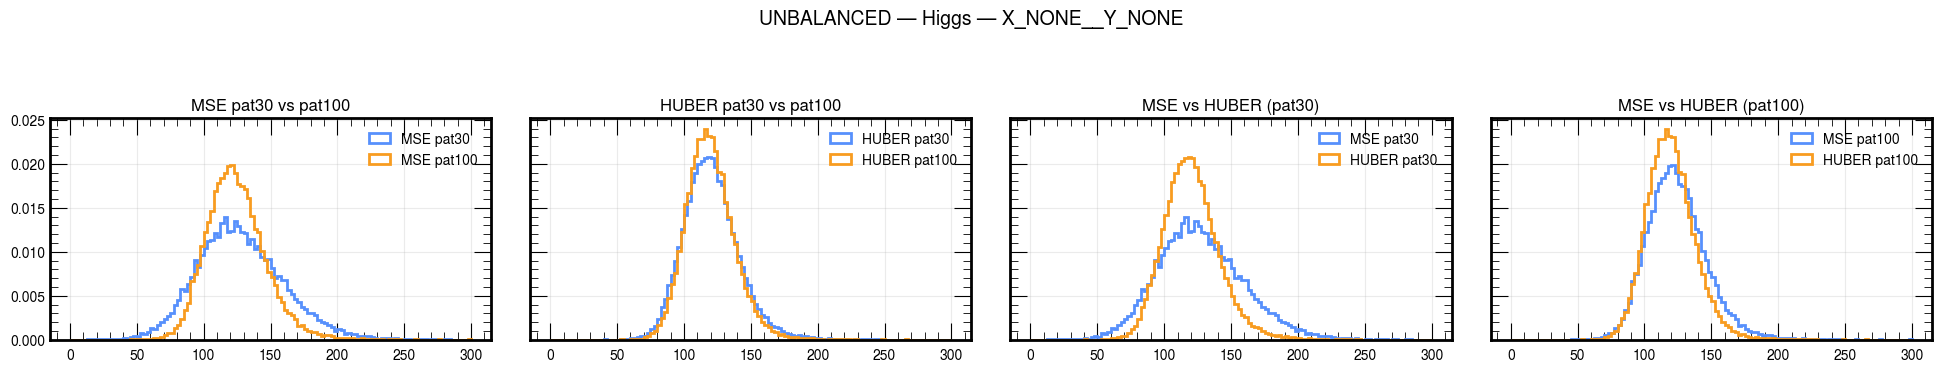

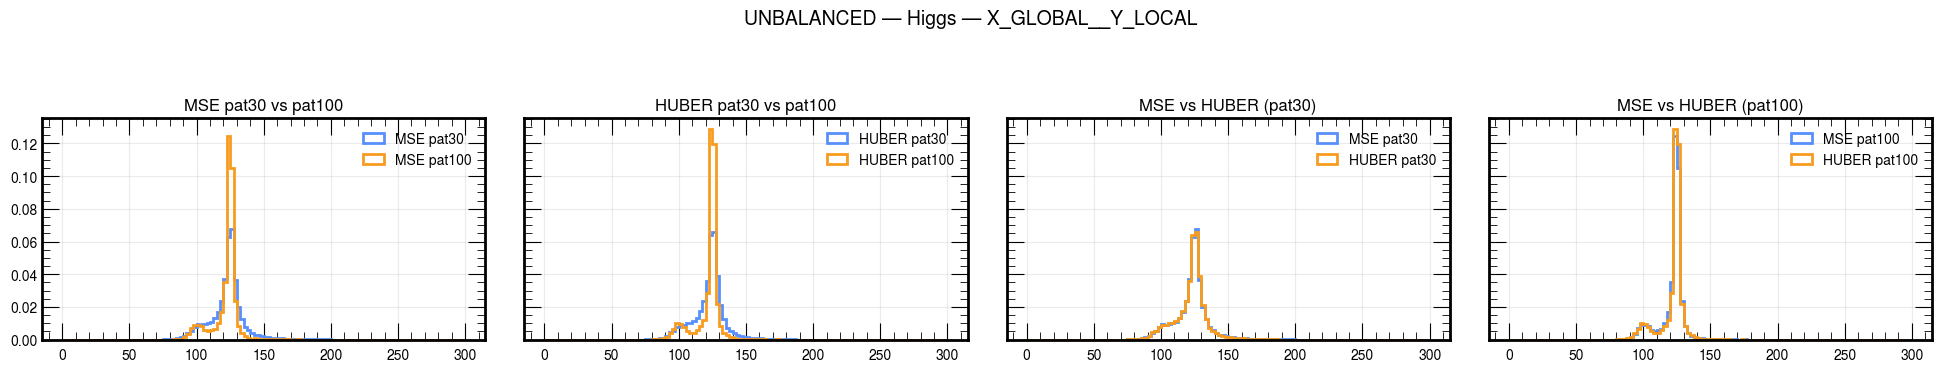

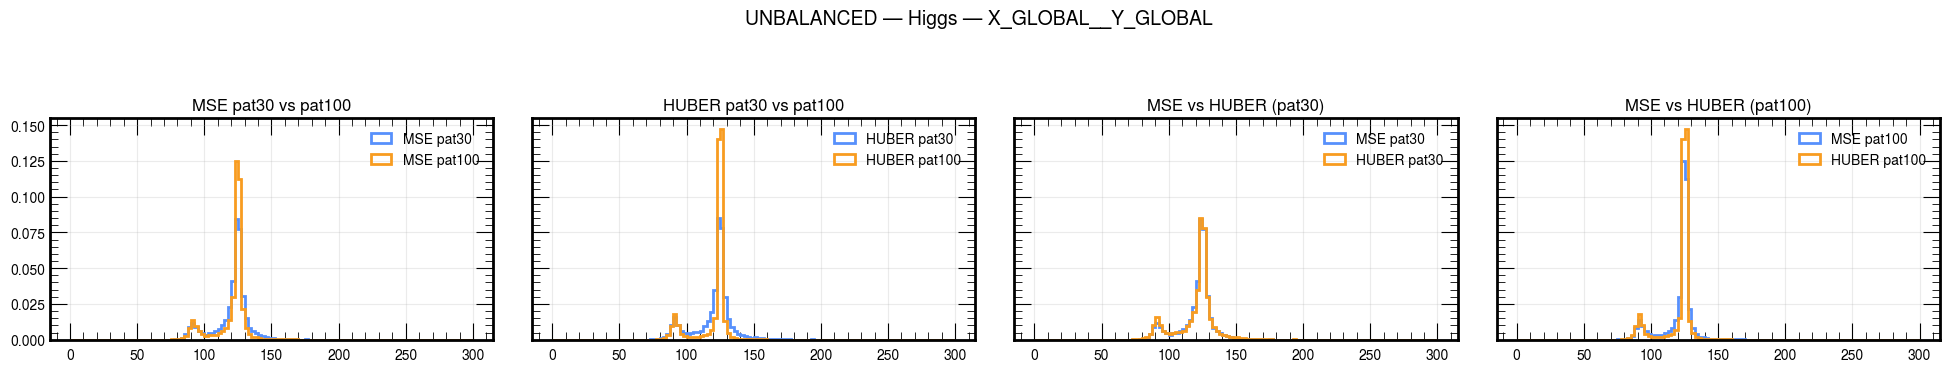

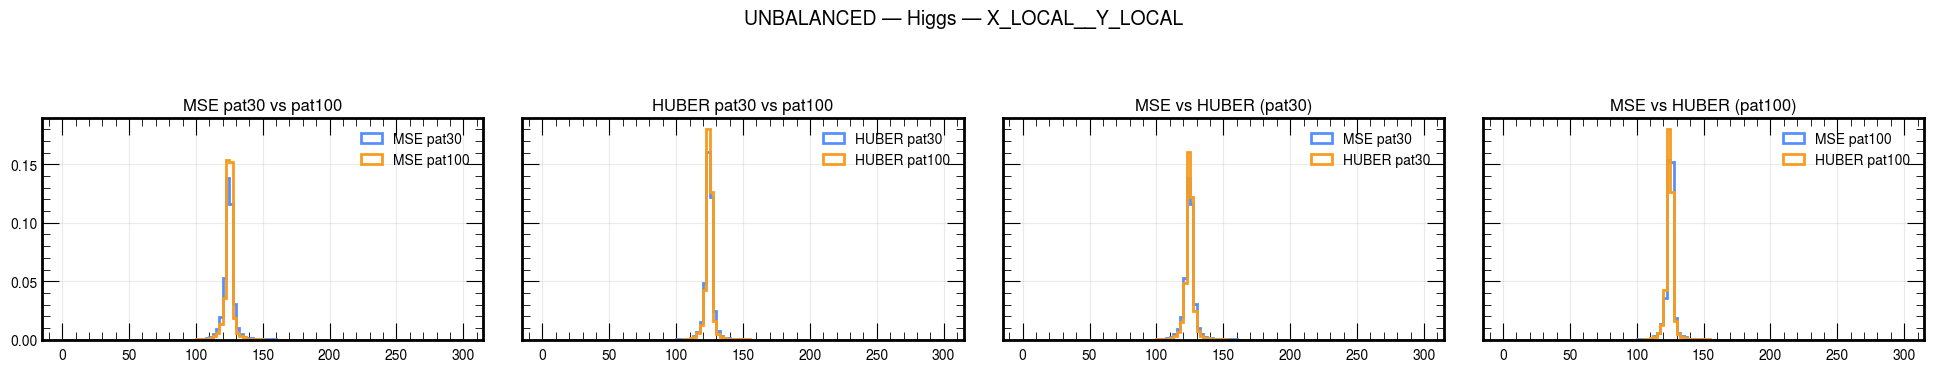

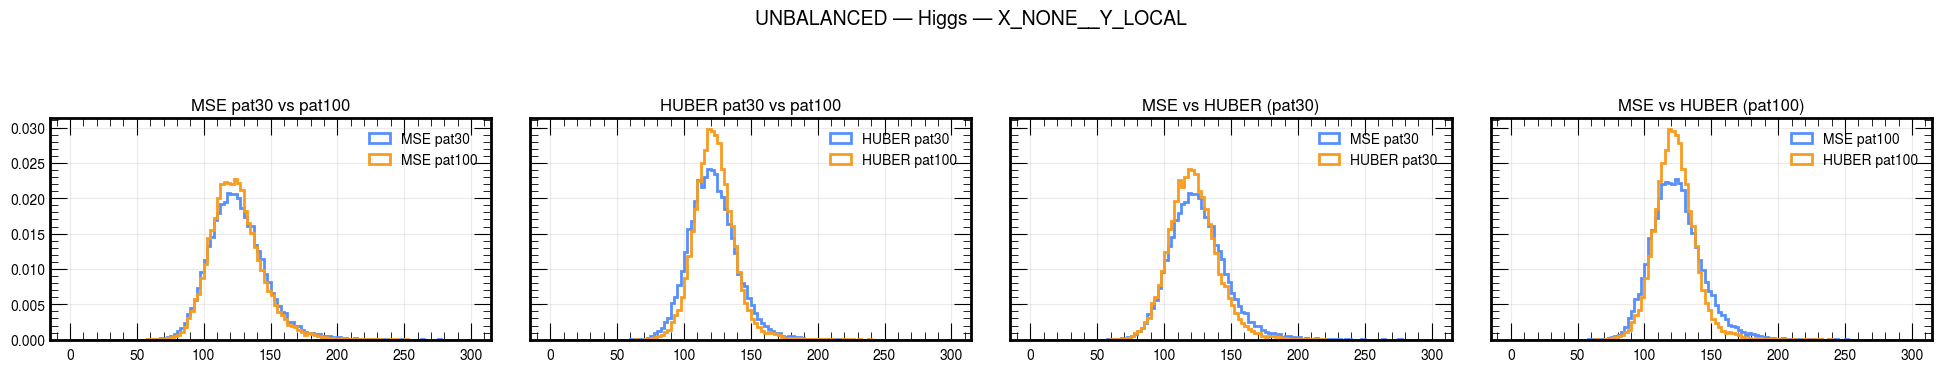

In [49]:
massesPlots.plot_mass_grid_by_mode(
    masses_a_pat30=masses_unb_h_mse_pat30,
    masses_a_pat100=masses_unb_h_mse_pat100,
    masses_b_pat30=masses_unb_h_huber_pat30,
    masses_b_pat100=masses_unb_h_huber_pat100,
    scaling_modes=SCALING_MODES,
    main_title="UNBALANCED — Higgs",
    label_a="MSE",
    label_b="HUBER",
    bins=120,
    range_=(0, 300),
    density=True,
    add_higgs_line=False,
)

# Analysis
---

In [50]:
window = (110, 140)

all_results = []

configs = [
    ("balanced",   "MSE",   30,  masses_bal_mse_pat30,   df_test_bal),
    ("balanced",   "MSE",   100, masses_bal_mse_pat100,  df_test_bal),
    ("balanced",   "HUBER", 30,  masses_bal_huber_pat30, df_test_bal),
    ("balanced",   "HUBER", 100, masses_bal_huber_pat100, df_test_bal),

    ("unbalanced", "MSE",   30,  masses_unbal_mse_pat30,   df_test_all),
    ("unbalanced", "MSE",   100, masses_unbal_mse_pat100,  df_test_all),
    ("unbalanced", "HUBER", 30,  masses_unbal_huber_pat30, df_test_all),
    ("unbalanced", "HUBER", 100, masses_unbal_huber_pat100, df_test_all),
]

for dataset_tag, loss_name, patience, masses_dict, df_test in configs:
    for mode in SCALING_MODES:
        df_tmp = df_test.copy()
        df_tmp["m_pred"] = np.asarray(masses_dict[mode])

        res = analysis.compute_S_over_B(
            df_tmp,
            mass_col="m_pred",
            window=window,
        )

        all_results.append({
            "dataset": dataset_tag,
            "loss": loss_name,
            "patience": patience,
            "mode": mode,
            "N_S": res["N_S"],
            "N_B": res["N_B"],
            "S_over_B": res["S_over_B"],
            "S_over_sqrtB": res["S_over_sqrtB"],
        })

df_SB_all = pd.DataFrame(all_results)
df_SB_all

,dataset,loss,patience,mode,N_S,N_B,S_over_B,S_over_sqrtB
0,balanced,MSE,30,X_NONE__Y_NONE,2737,1809,1.512991,64.351032
1,balanced,MSE,30,X_GLOBAL__Y_LOCAL,4481,1072,4.180037,136.860320
2,balanced,MSE,30,X_GLOBAL__Y_GLOBAL,4028,1676,2.403341,98.390339
3,balanced,MSE,30,X_LOCAL__Y_LOCAL,6454,428,15.079439,311.965865
4,balanced,MSE,30,X_NONE__Y_LOCAL,3864,1259,3.069102,108.899091
5,balanced,MSE,100,X_NONE__Y_NONE,3473,2048,1.695801,76.743183
6,balanced,MSE,100,X_GLOBAL__Y_LOCAL,5147,942,5.463907,167.698322
7,balanced,MSE,100,X_GLOBAL__Y_GLOBAL,4409,1928,2.286826,100.412223
8,balanced,MSE,100,X_LOCAL__Y_LOCAL,6518,378,17.243386,335.249745
9,balanced,MSE,100,X_NONE__Y_LOCAL,4088,1304,3.134969,113.206690


In [51]:
df_SB_all = df_SB_all.sort_values(
    ["dataset", "loss", "patience", "S_over_sqrtB"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

df_SB_all

,dataset,loss,patience,mode,N_S,N_B,S_over_B,S_over_sqrtB
0,balanced,HUBER,30,X_LOCAL__Y_LOCAL,6712,369,18.189702,349.412763
1,balanced,HUBER,30,X_GLOBAL__Y_LOCAL,4903,767,6.392438,177.037069
2,balanced,HUBER,30,X_NONE__Y_LOCAL,3340,820,4.073171,116.637859
3,balanced,HUBER,30,X_GLOBAL__Y_GLOBAL,3870,1508,2.566313,99.657570
4,balanced,HUBER,30,X_NONE__Y_NONE,3163,1774,1.782976,75.096965
5,balanced,HUBER,100,X_LOCAL__Y_LOCAL,6946,299,23.230769,401.697552
6,balanced,HUBER,100,X_GLOBAL__Y_LOCAL,4969,839,5.922527,171.548931
7,balanced,HUBER,100,X_GLOBAL__Y_GLOBAL,5301,2051,2.584593,117.050958
8,balanced,HUBER,100,X_NONE__Y_LOCAL,3734,1286,2.903577,104.124716
9,balanced,HUBER,100,X_NONE__Y_NONE,3454,1636,2.111247,85.394654


In [52]:
df_SB_pivot = df_SB_all.pivot_table(
    index=["dataset", "loss", "patience", "mode"],
    values=["N_S", "N_B", "S_over_B", "S_over_sqrtB"],
    aggfunc="first",
).reset_index()

df_SB_pivot

,dataset,loss,patience,mode,N_B,N_S,S_over_B,S_over_sqrtB
0,balanced,HUBER,30,X_GLOBAL__Y_GLOBAL,1508,3870,2.566313,99.657570
1,balanced,HUBER,30,X_GLOBAL__Y_LOCAL,767,4903,6.392438,177.037069
2,balanced,HUBER,30,X_LOCAL__Y_LOCAL,369,6712,18.189702,349.412763
3,balanced,HUBER,30,X_NONE__Y_LOCAL,820,3340,4.073171,116.637859
4,balanced,HUBER,30,X_NONE__Y_NONE,1774,3163,1.782976,75.096965
5,balanced,HUBER,100,X_GLOBAL__Y_GLOBAL,2051,5301,2.584593,117.050958
6,balanced,HUBER,100,X_GLOBAL__Y_LOCAL,839,4969,5.922527,171.548931
7,balanced,HUBER,100,X_LOCAL__Y_LOCAL,299,6946,23.230769,401.697552
8,balanced,HUBER,100,X_NONE__Y_LOCAL,1286,3734,2.903577,104.124716
9,balanced,HUBER,100,X_NONE__Y_NONE,1636,3454,2.111247,85.394654


In [53]:
df_best = (
    df_SB_all.sort_values("S_over_sqrtB", ascending=False)
    .groupby(["dataset", "loss", "patience"], as_index=False)
    .first()
)

df_best

,dataset,loss,patience,mode,N_S,N_B,S_over_B,S_over_sqrtB
0,balanced,HUBER,30,X_LOCAL__Y_LOCAL,6712,369,18.189702,349.412763
1,balanced,HUBER,100,X_LOCAL__Y_LOCAL,6946,299,23.230769,401.697552
2,balanced,MSE,30,X_LOCAL__Y_LOCAL,6454,428,15.079439,311.965865
3,balanced,MSE,100,X_LOCAL__Y_LOCAL,6518,378,17.243386,335.249745
4,unbalanced,HUBER,30,X_LOCAL__Y_LOCAL,25218,161,156.633540,1987.456822
5,unbalanced,HUBER,100,X_LOCAL__Y_LOCAL,25272,175,144.411429,1910.383632
6,unbalanced,MSE,30,X_LOCAL__Y_LOCAL,25003,215,116.293023,1705.190447
7,unbalanced,MSE,100,X_LOCAL__Y_LOCAL,25165,208,120.985577,1744.878805


In [54]:
df_SB_all.round(3)

,dataset,loss,patience,mode,N_S,N_B,S_over_B,S_over_sqrtB
0,balanced,HUBER,30,X_LOCAL__Y_LOCAL,6712,369,18.190,349.413
1,balanced,HUBER,30,X_GLOBAL__Y_LOCAL,4903,767,6.392,177.037
2,balanced,HUBER,30,X_NONE__Y_LOCAL,3340,820,4.073,116.638
3,balanced,HUBER,30,X_GLOBAL__Y_GLOBAL,3870,1508,2.566,99.658
4,balanced,HUBER,30,X_NONE__Y_NONE,3163,1774,1.783,75.097
5,balanced,HUBER,100,X_LOCAL__Y_LOCAL,6946,299,23.231,401.698
6,balanced,HUBER,100,X_GLOBAL__Y_LOCAL,4969,839,5.923,171.549
7,balanced,HUBER,100,X_GLOBAL__Y_GLOBAL,5301,2051,2.585,117.051
8,balanced,HUBER,100,X_NONE__Y_LOCAL,3734,1286,2.904,104.125
9,balanced,HUBER,100,X_NONE__Y_NONE,3454,1636,2.111,85.395


In [55]:
df_SB_all = pd.DataFrame(all_results)

df_SB_all = df_SB_all.sort_values(
    by="S_over_B",
    ascending=False
).reset_index(drop=True)

df_SB_all

,dataset,loss,patience,mode,N_S,N_B,S_over_B,S_over_sqrtB
0,unbalanced,HUBER,30,X_LOCAL__Y_LOCAL,25218,161,156.633540,1987.456822
1,unbalanced,HUBER,100,X_LOCAL__Y_LOCAL,25272,175,144.411429,1910.383632
2,unbalanced,MSE,100,X_LOCAL__Y_LOCAL,25165,208,120.985577,1744.878805
3,unbalanced,MSE,30,X_LOCAL__Y_LOCAL,25003,215,116.293023,1705.190447
4,balanced,HUBER,100,X_LOCAL__Y_LOCAL,6946,299,23.230769,401.697552
5,balanced,HUBER,30,X_LOCAL__Y_LOCAL,6712,369,18.189702,349.412763
6,balanced,MSE,100,X_LOCAL__Y_LOCAL,6518,378,17.243386,335.249745
7,unbalanced,HUBER,100,X_NONE__Y_LOCAL,18116,1169,15.497006,529.852584
8,balanced,MSE,30,X_LOCAL__Y_LOCAL,6454,428,15.079439,311.965865
9,unbalanced,HUBER,30,X_NONE__Y_LOCAL,15386,1117,13.774396,460.361654


# Presentazione
---

In [59]:
df_SB_all.head(10)

,dataset,loss,patience,mode,N_S,N_B,S_over_B,S_over_sqrtB
0,unbalanced,HUBER,30,X_LOCAL__Y_LOCAL,25218,161,156.633540,1987.456822
1,unbalanced,HUBER,100,X_LOCAL__Y_LOCAL,25272,175,144.411429,1910.383632
2,unbalanced,MSE,100,X_LOCAL__Y_LOCAL,25165,208,120.985577,1744.878805
3,unbalanced,MSE,30,X_LOCAL__Y_LOCAL,25003,215,116.293023,1705.190447
4,balanced,HUBER,100,X_LOCAL__Y_LOCAL,6946,299,23.230769,401.697552
5,balanced,HUBER,30,X_LOCAL__Y_LOCAL,6712,369,18.189702,349.412763
6,balanced,MSE,100,X_LOCAL__Y_LOCAL,6518,378,17.243386,335.249745
7,unbalanced,HUBER,100,X_NONE__Y_LOCAL,18116,1169,15.497006,529.852584
8,balanced,MSE,30,X_LOCAL__Y_LOCAL,6454,428,15.079439,311.965865
9,unbalanced,HUBER,30,X_NONE__Y_LOCAL,15386,1117,13.774396,460.361654


In [61]:
df_global = df_SB_all[df_SB_all["mode"] == "X_GLOBAL__Y_GLOBAL"]

df_global = df_global.sort_values(
    by="S_over_B",
    ascending=False
).reset_index(drop=True)

df_global

,dataset,loss,patience,mode,N_S,N_B,S_over_B,S_over_sqrtB
0,unbalanced,HUBER,100,X_GLOBAL__Y_GLOBAL,21712,3620,5.997790,360.865650
1,unbalanced,HUBER,30,X_GLOBAL__Y_GLOBAL,19725,3418,5.770919,337.389049
2,unbalanced,MSE,100,X_GLOBAL__Y_GLOBAL,21452,3765,5.697742,349.611169
3,unbalanced,MSE,30,X_GLOBAL__Y_GLOBAL,20529,3666,5.599836,339.056102
4,balanced,HUBER,100,X_GLOBAL__Y_GLOBAL,5301,2051,2.584593,117.050958
5,balanced,HUBER,30,X_GLOBAL__Y_GLOBAL,3870,1508,2.566313,99.657570
6,balanced,MSE,30,X_GLOBAL__Y_GLOBAL,4028,1676,2.403341,98.390339
7,balanced,MSE,100,X_GLOBAL__Y_GLOBAL,4409,1928,2.286826,100.412223


# max_epochs = 5000

In [ ]:
results_unbalanced_huber_pat100_ep5000 = {}

for mode, mode_dir in paths_unbalanced.items():
    print("\n" + "="*90)
    print(f"TRAIN UNBALANCED — {mode} — HUBER pat100 ep5000")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="huber",
        huber_delta=1.0,
        patience=100,
        epochs=5000,
    )

    results_unbalanced_huber_pat100_ep5000[mode] = res


TRAIN UNBALANCED — X_NONE__Y_NONE — HUBER pat100 ep5000
[ep    1] train=0.852451  val=0.479842  best=0.479842  bad=0/100
[ep   10] train=0.430025  val=0.428030  best=0.428030  bad=0/100
[ep   20] train=0.356469  val=0.379652  best=0.337078  bad=1/100
[ep   30] train=0.286256  val=0.301780  best=0.274328  bad=1/100
[ep   40] train=0.272861  val=0.293023  best=0.258498  bad=1/100
[ep   50] train=0.263150  val=0.250368  best=0.250368  bad=0/100
[ep   60] train=0.251765  val=0.250953  best=0.246717  bad=1/100
[ep   70] train=0.249633  val=0.267673  best=0.238438  bad=8/100
[ep   80] train=0.338885  val=0.288131  best=0.229445  bad=4/100
[ep   90] train=0.243905  val=0.270384  best=0.228980  bad=2/100
[ep  100] train=0.231943  val=0.233316  best=0.221396  bad=1/100
[ep  110] train=0.231527  val=0.238882  best=0.221396  bad=11/100
[ep  120] train=0.230864  val=0.254699  best=0.218830  bad=8/100
[ep  130] train=0.226312  val=0.222068  best=0.215543  bad=7/100
[ep  140] train=0.227961  val=0.

In [ ]:
loss_tag = "HUBER_d1_pat100_ep5000"

for mode, res in results_unbalanced_huber_pat100.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

In [ ]:
for mode in SCALING_MODES:

    lossPlots.plot_loss_overlay(
        {
            "HUBER_pat100_ep1000": results_unbalanced_huber_pat100[mode],
            "HUBER_pat100_ep5000": results_unbalanced_huber_pat100_ep5000[mode],
        },
        title=f"VAL loss — UNBALANCED — {mode} — HUBER pat100: ep1000 vs ep5000",
        which="val",
        logy=False,
    )

In [ ]:
# Predictions:
preds_unbalanced_huber_pat100_ep5000 = {}

for mode in SCALING_MODES:
    res = results_unbalanced_huber_pat100_ep5000[mode]

    df_pred = model.predict_tau_corr_auto(
        df=df_all_test,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_unbalanced_huber_pat100_ep5000[mode] = df_pred

In [ ]:
# Masses:
# UNBALANCED — HUBER pat100 — ep5000
masses_unbal_huber_pat100_ep5000 = {}

for mode in SCALING_MODES:
    
    dfp = preds_unbal_huber_pat100_ep5000[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_all["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau1_eta"].to_numpy(),
        df_test_all["tau1_phi"].to_numpy(),
        df_test_all["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_all["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau2_eta"].to_numpy(),
        df_test_all["tau2_phi"].to_numpy(),
        df_test_all["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_unbal_huber_pat100_ep5000[mode] = m
    print(mode, "UNBALANCED HUBER pat100 ep5000 done:", float(np.mean(m)), float(np.std(m)))

In [ ]:
# Saving:
OUT = "../results/masses"

np.savez_compressed(
    os.path.join(OUT, "masses_unbal_huber_pat100_ep5000.npz"),
    **masses_unbal_huber_pat100_ep5000
)

mask_dy = df_test_all["class"].to_numpy() == 0
mask_h  = df_test_all["class"].to_numpy() == 1

masses_unbal_huber_pat100_ep5000_dy = {
    mode: m[mask_dy]
    for mode, m in masses_unbal_huber_pat100_ep5000.items()
}

masses_unbal_huber_pat100_ep5000_h = {
    mode: m[mask_h]
    for mode, m in masses_unbal_huber_pat100_ep5000.items()
}

np.savez_compressed(
    os.path.join(OUT, "masses_unbal_huber_pat100_ep5000_dy.npz"),
    **masses_unbal_huber_pat100_ep5000_dy
)

np.savez_compressed(
    os.path.join(OUT, "masses_unbal_huber_pat100_ep5000_h.npz"),
    **masses_unbal_huber_pat100_ep5000_h
)

In [ ]:
SB_rows = []

for mode in SCALING_MODES:

    # ep1000
    df_tmp = df_test_all.copy()
    df_tmp["m_pred"] = masses_unbal_huber_pat100[mode]

    res1000 = analysis.compute_S_over_B(
        df_tmp,
        mass_col="m_pred",
        window=(110,130),
    )

    # ep5000
    df_tmp = df_test_all.copy()
    df_tmp["m_pred"] = masses_unbal_huber_pat100_ep5000[mode]

    res5000 = analysis.compute_S_over_B(
        df_tmp,
        mass_col="m_pred",
        window=(110,130),
    )

    SB_rows.append({
        "mode": mode,

        "N_S_ep1000": res1000["N_S"],
        "N_B_ep1000": res1000["N_B"],
        "S/B_ep1000": res1000["S_over_B"],

        "N_S_ep5000": res5000["N_S"],
        "N_B_ep5000": res5000["N_B"],
        "S/B_ep5000": res5000["S_over_B"],
    })

df_SB_compare = pd.DataFrame(SB_rows)

df_SB_compare["delta_S/B"] = df_SB_compare["S/B_ep5000"] - df_SB_compare["S/B_ep1000"]
df_SB_compare["ratio"] = df_SB_compare["S/B_ep5000"] / df_SB_compare["S/B_ep1000"]

df_SB_compare = df_SB_compare.sort_values("S/B_ep5000", ascending=False)
df_SB_compare